# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
  
# data (as pandas dataframes) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 
  
# metadata 
print(metro_interstate_traffic_volume.metadata) 
  
# variable information 
print(metro_interstate_traffic_volume.variables) 

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

In [2]:
import pandas as pd

data = pd.concat([X, y], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [3]:
data["holiday"] = data["holiday"].replace("None", 0).fillna(0)

In [4]:
data= data.sample(n=5000, random_state=42)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 35748 to 2255
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              5000 non-null   object 
 1   temp                 5000 non-null   float64
 2   rain_1h              5000 non-null   float64
 3   snow_1h              5000 non-null   float64
 4   clouds_all           5000 non-null   int64  
 5   weather_main         5000 non-null   object 
 6   weather_description  5000 non-null   object 
 7   date_time            5000 non-null   object 
 8   traffic_volume       5000 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 390.6+ KB


# Generating synthetic data

In [5]:
# Import SDV libraries
import warnings
warnings.filterwarnings('ignore')
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = len(data)

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 197.75it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 137.51it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 111.39it/s]|
Column Shapes Score: 84.22%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 78.88it/s]|
Column Pair Trends Score: 66.83%

Overall Score (Average): 75.53%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 508.71it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 246.25it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 204.39it/s]|
Column Shapes Score: 77.56%

(2/2) Evaluating 

,Model,Diagnostic Score,Quality Score
0,TVAE,1.0,0.852997
1,CTGAN,1.0,0.755272
2,CopulaGAN,1.0,0.719811
3,GaussianCopula,1.0,0.573533



Best model by quality score: TVAE


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,0,271.019258,0.0,0.0,90,Clouds,overcast clouds,2013-01-26 02:07:01,147
1,0,260.220891,0.0,0.0,1,Clear,sky is clear,2018-05-25 15:36:38,435
2,0,287.551141,0.0,0.0,78,Clouds,broken clouds,2013-07-10 07:27:21,3286
3,0,283.129197,0.0,0.0,2,Clear,sky is clear,2018-02-12 16:36:50,1
4,0,284.115951,0.0,0.0,90,Mist,mist,2013-01-13 18:01:52,917


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 468.95it/s]|
Column Shapes Score: 83.36%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 262.50it/s]|
Column Pair Trends Score: 66.83%

Overall Score (Average): 75.1%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 461.15it/s]|
Column Shapes Score: 76.24%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 309.80it/s]|
Column Pair Trends Score: 66.4%

Overall Score (Average): 71.32%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 348.52it/s]|
Column Shapes Score: 92.67%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 239.66it/s]|
Column Pair Trends Score: 80.88%

Overall Score (Average): 86.77%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 398.14it/s]|
Column Shapes Score: 70.24%

(2/2) Evaluating Column Pair Trends: |██

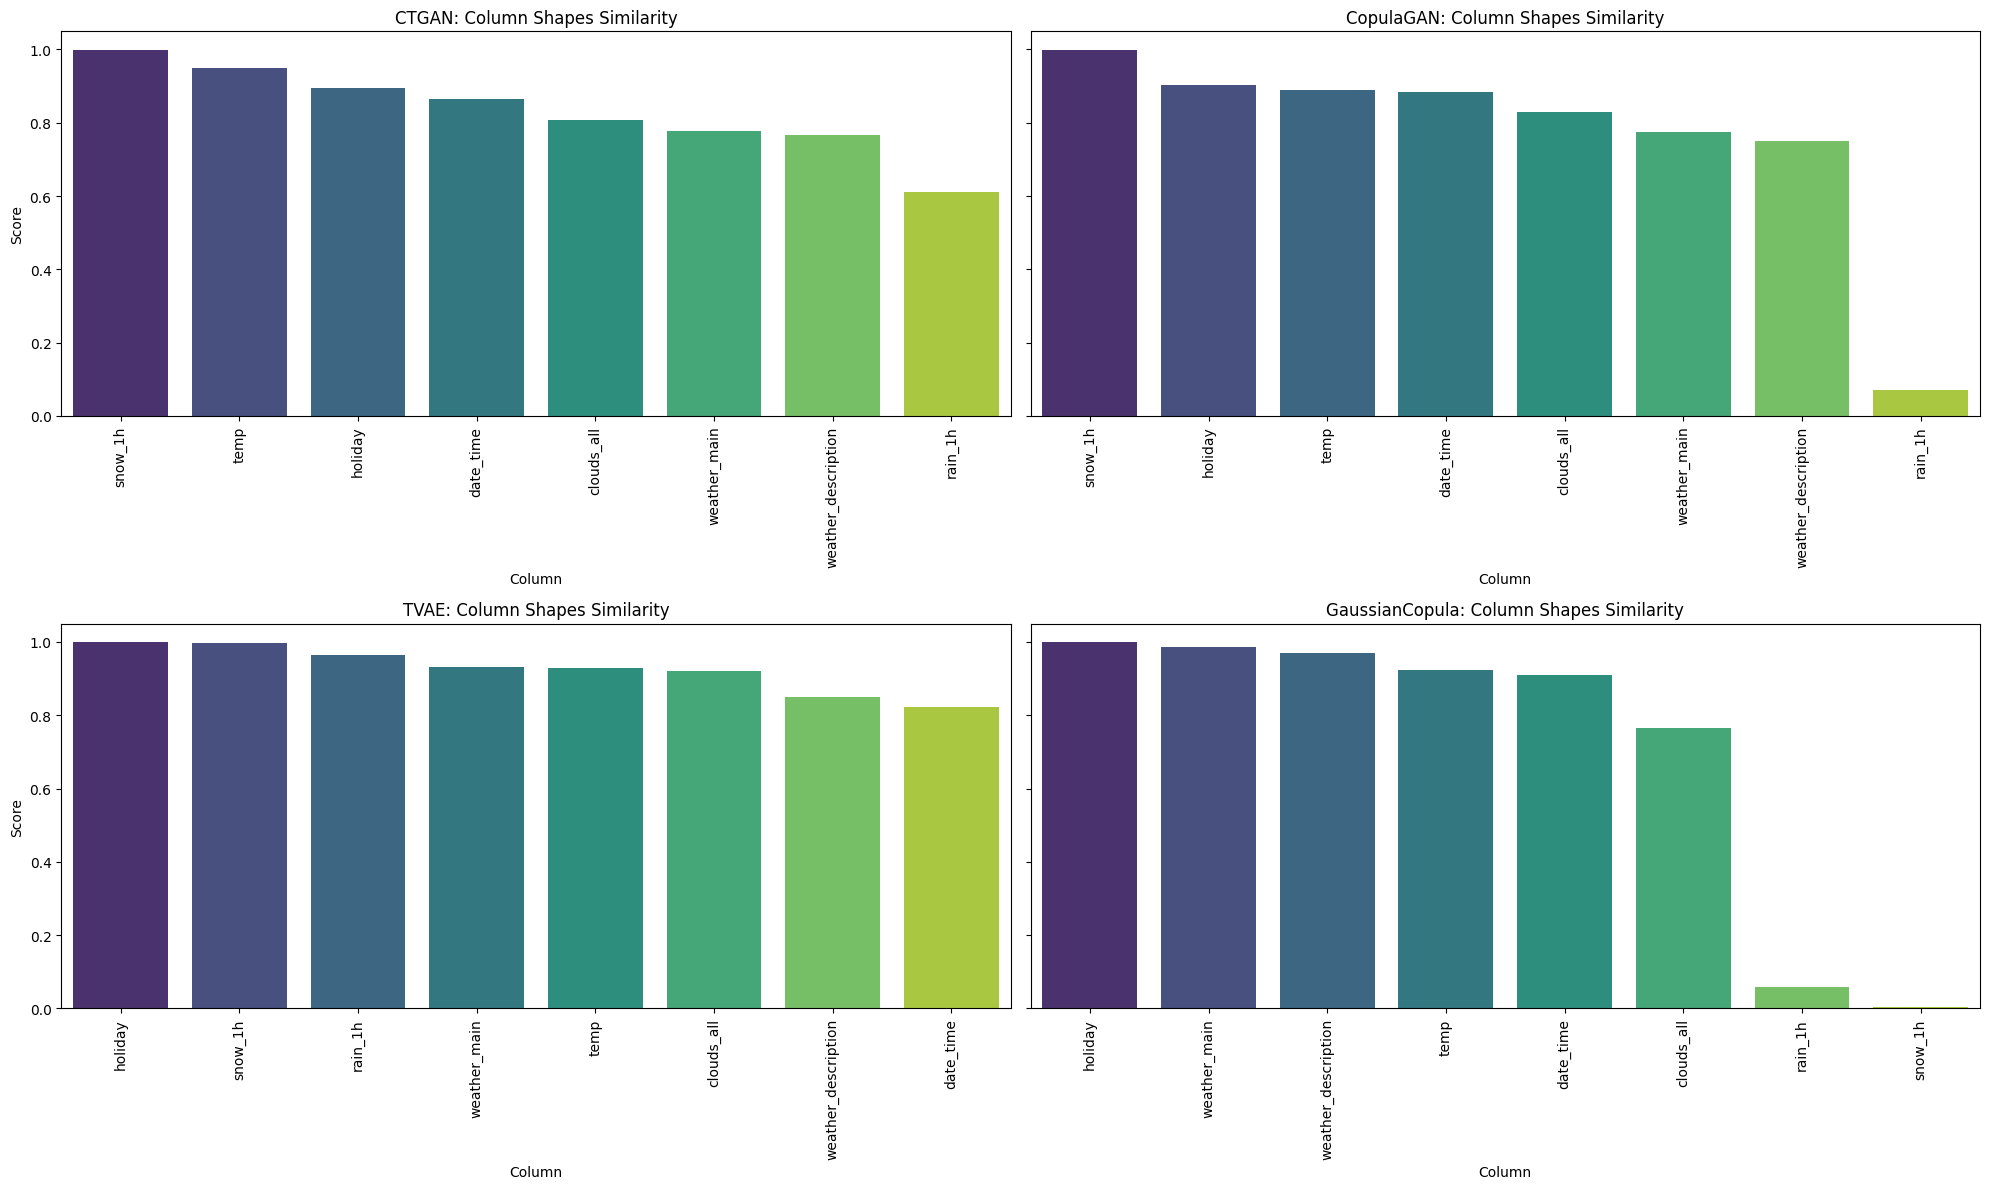

,Column,Metric,Score,Model
0,snow_1h,KSComplement,0.9982,CTGAN
1,temp,KSComplement,0.9482,CTGAN
2,holiday,TVComplement,0.8944,CTGAN
3,date_time,KSComplement,0.8636,CTGAN
4,clouds_all,KSComplement,0.8070,CTGAN
5,weather_main,TVComplement,0.7782,CTGAN
6,weather_description,TVComplement,0.7674,CTGAN
7,rain_1h,KSComplement,0.6118,CTGAN
8,snow_1h,KSComplement,0.9982,CopulaGAN
9,holiday,TVComplement,0.9034,CopulaGAN


In [6]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [7]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors="coerce").dropna().to_numpy()
    synth = pd.to_numeric(synth, errors="coerce").dropna().to_numpy()

    if len(real) == 0 or len(synth) == 0:
        return np.array([0.5, 0.5]), np.array([0.5, 0.5])

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)

    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": float(js_div)})

    return pd.DataFrame(results).sort_values("JS_Divergence", ascending=False).reset_index(drop=True)

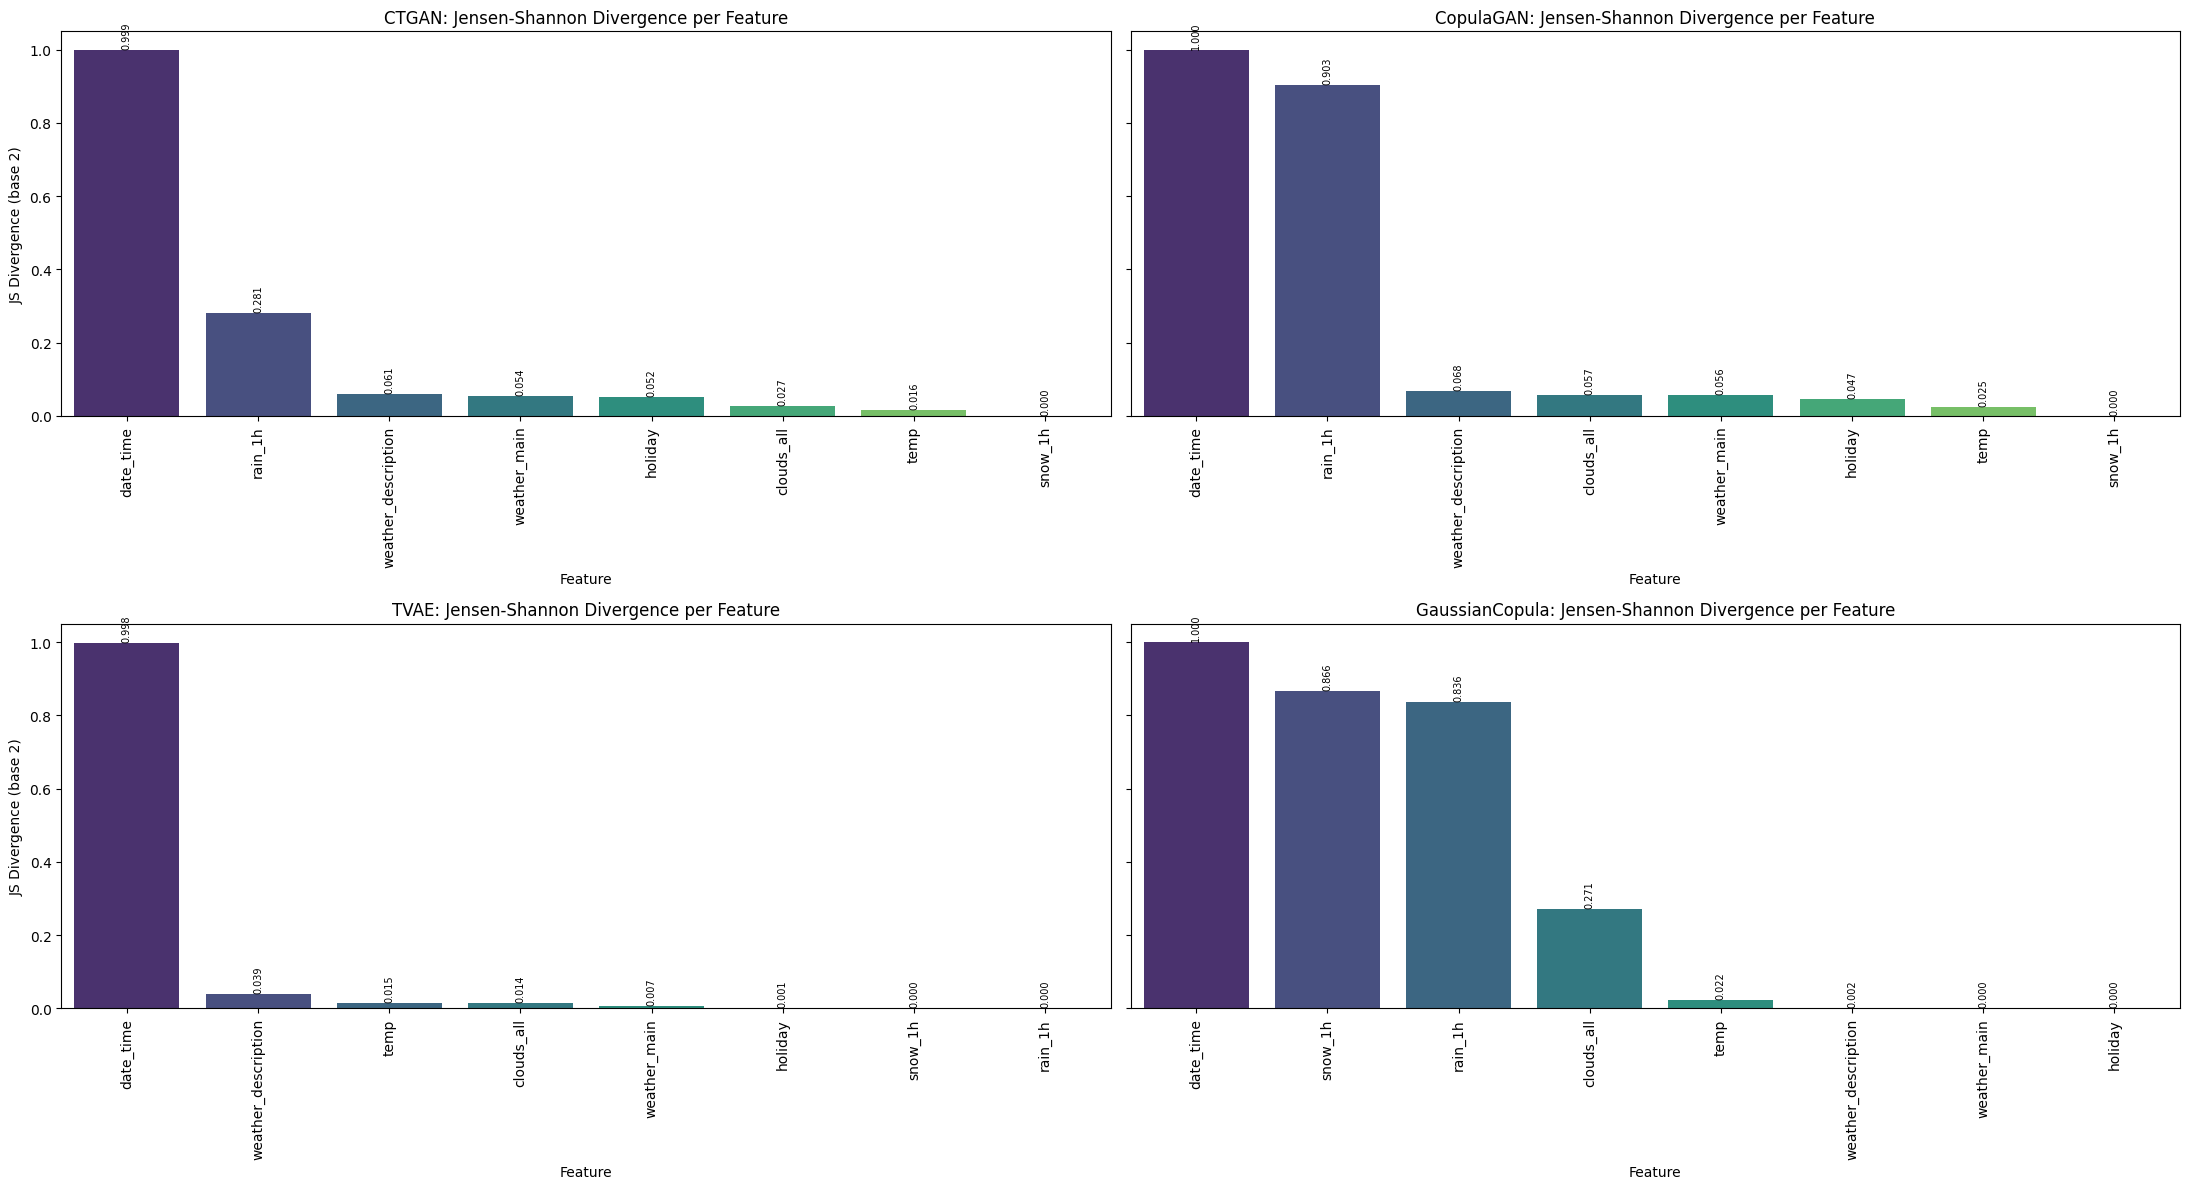

,Feature,JS_Divergence,Model
0,date_time,0.998561,CTGAN
1,rain_1h,0.280612,CTGAN
2,weather_description,0.060727,CTGAN
3,weather_main,0.053754,CTGAN
4,holiday,0.051837,CTGAN
5,clouds_all,0.027413,CTGAN
6,temp,0.016061,CTGAN
7,snow_1h,0.000000,CTGAN
8,date_time,1.000000,CopulaGAN
9,rain_1h,0.903054,CopulaGAN


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

js_results_by_model = {}

for model_name in model_order:
    real_eval = data.drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()

    common_cols = real_eval.columns.intersection(synth_eval.columns)
    real_eval = real_eval[common_cols]
    synth_eval = synth_eval[common_cols]

    js_df = compute_js_divergence(
        real_eval,
        synth_eval,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)

    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]

    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
temp: 0.0029
rain_1h: 0.0031
snow_1h: 0.0010
clouds_all: 0.1141

CopulaGAN - Wasserstein Distance:
temp: 0.0059
rain_1h: 0.0099
snow_1h: 0.0010
clouds_all: 0.0986

TVAE - Wasserstein Distance:
temp: 0.0031
rain_1h: 0.0038
snow_1h: 0.0010
clouds_all: 0.0310

GaussianCopula - Wasserstein Distance:
temp: 0.0036
rain_1h: 0.0908
snow_1h: 0.7362
clouds_all: 0.1175

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,TVAE,0.009702,0.003410,0.030964
1,CopulaGAN,0.028848,0.007872,0.098626
2,CTGAN,0.030300,0.003024,0.114128
3,GaussianCopula,0.237024,0.104147,0.736224


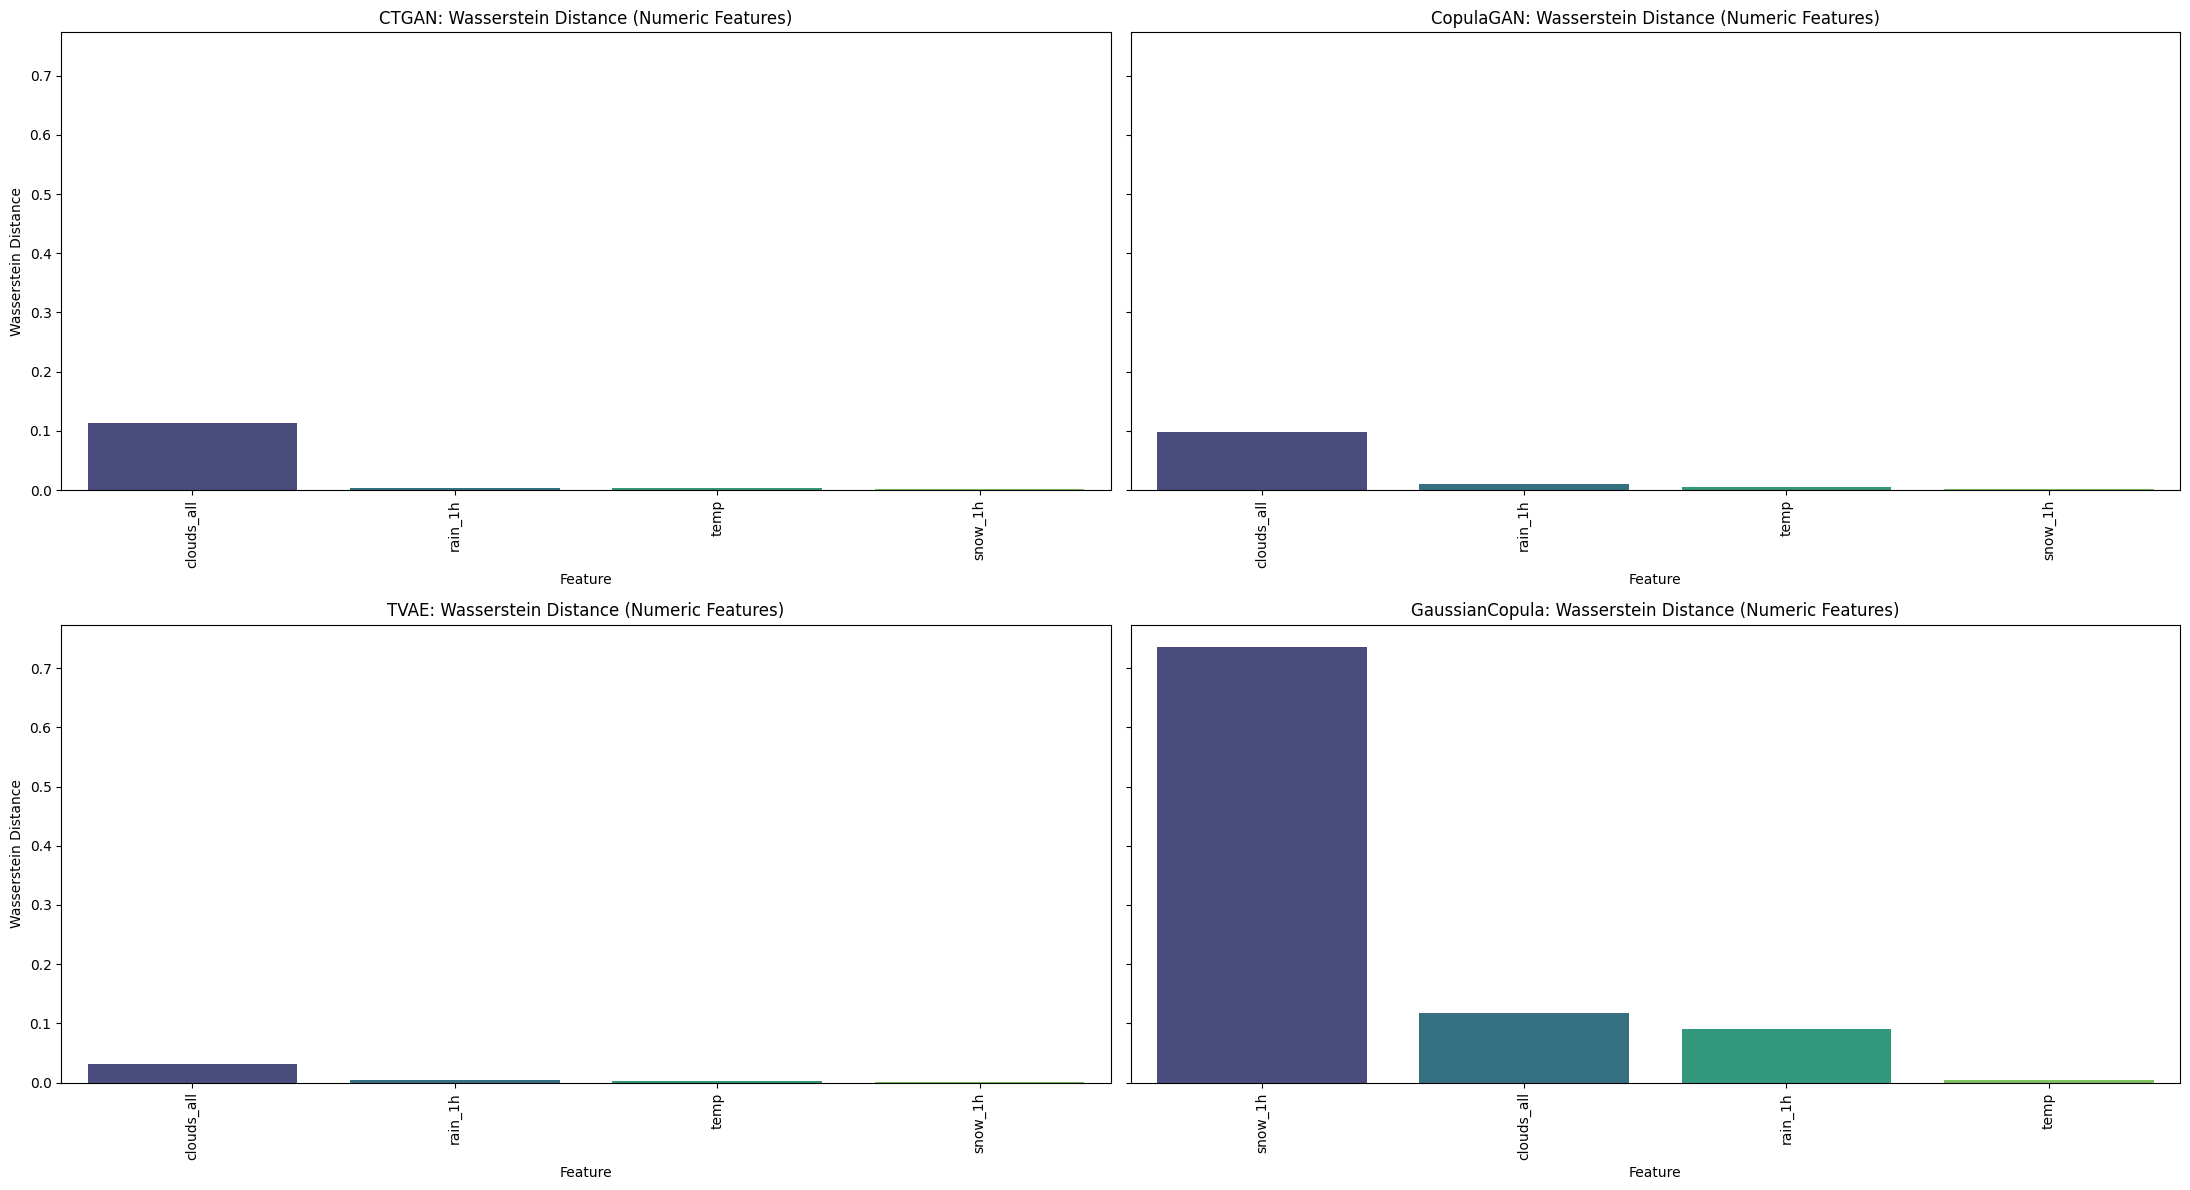

In [9]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

# Use numeric features only (Wasserstein here is numeric-distribution based)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data[feature_cols]),
    columns=feature_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name][data.columns].copy()

    # keep same numeric feature set/order
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in feature_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, float(dist)))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": float(dist_df["Wasserstein_Distance"].mean()),
        "Median_Wasserstein": float(dist_df["Wasserstein_Distance"].median()),
        "Max_Wasserstein": float(dist_df["Wasserstein_Distance"].max()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance (Numeric Features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [10]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6922

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6187

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.6658

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6922

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6172

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.6658

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6922

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6595

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.6899

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.6922

Intra-set Similarity (Synthetic):
Max = 0.9998, Avg = 0.6082

Cross-set Similarity (Real vs Synthetic):
Max = 0.9902, Avg = 0.5708


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.692223,1.000000,0.618701,1.000000,0.665849
1,CopulaGAN,1.0,0.692223,1.000000,0.617231,0.999995,0.665781
2,TVAE,1.0,0.692223,1.000000,0.659464,1.000000,0.689928
3,GaussianCopula,1.0,0.692223,0.999784,0.608196,0.990189,0.570833


### 1.5 t-SNE Visualization


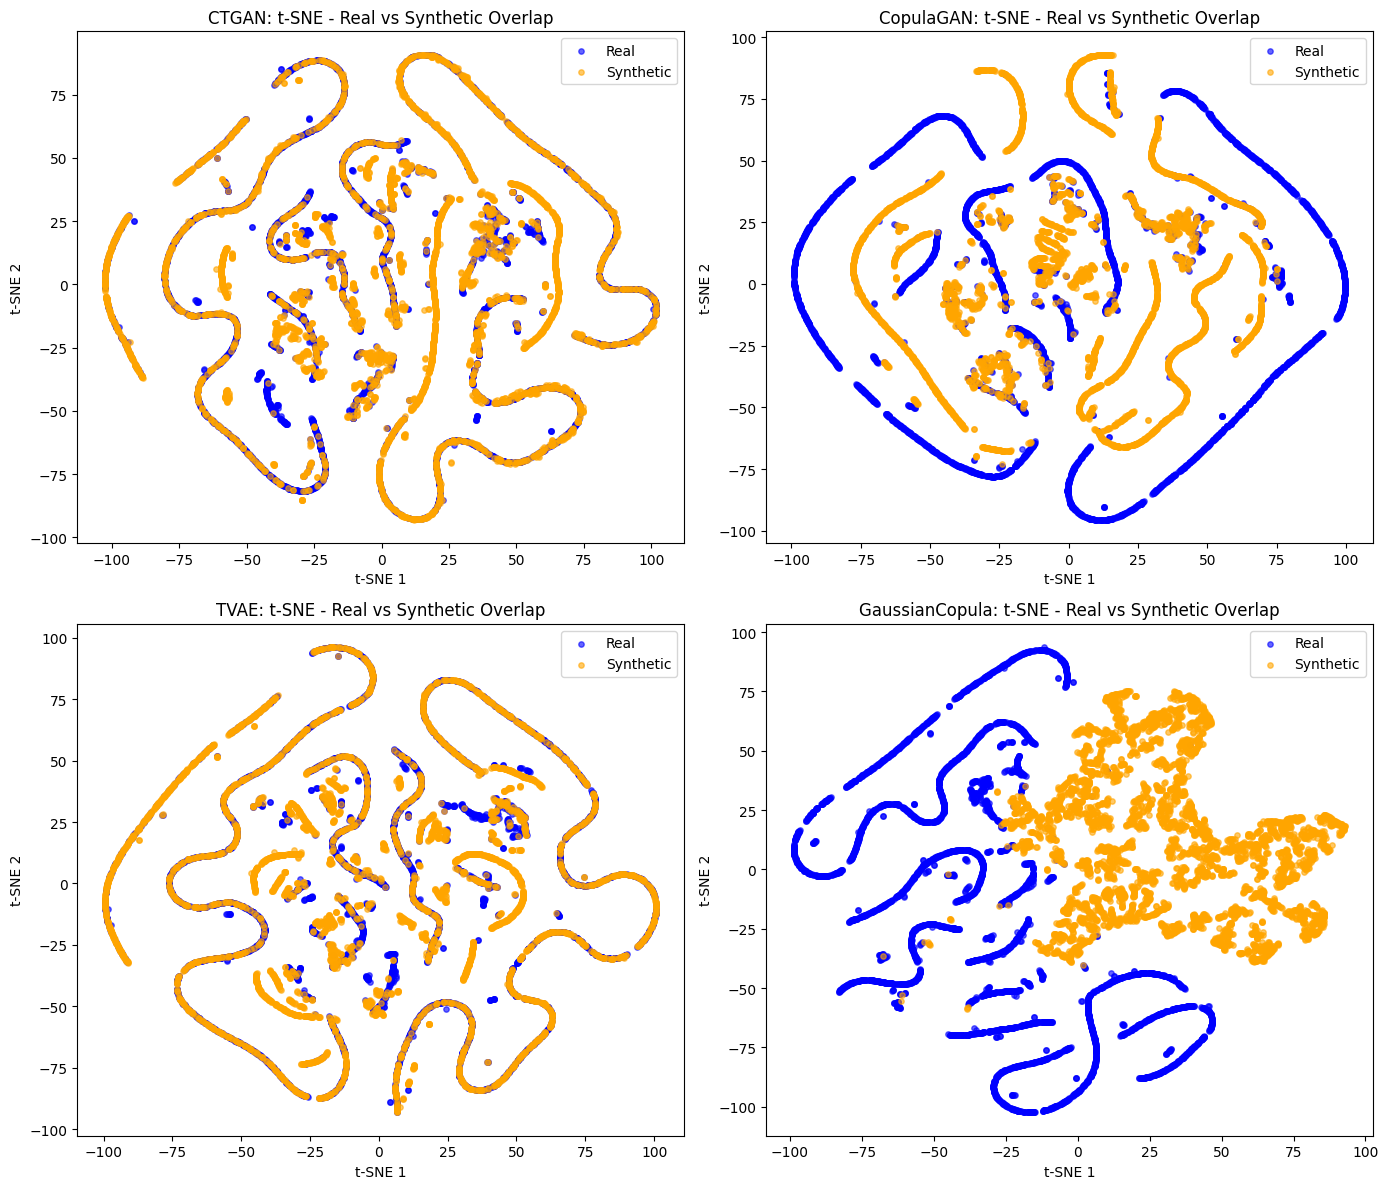

In [11]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"
date_col = "date_time"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns].copy()
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "traffic_volume"
date_col = "date_time"

drop_cols = [c for c in [target_col, date_col] if c in data.columns]
real_features = data.drop(columns=drop_cols, errors="ignore").copy()

# keep numeric only for RBF MMD
real_features = real_features.select_dtypes(include=[np.number]).copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": float(mmd_score)})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.009663
CopulaGAN - MMD score: 0.018567
TVAE - MMD score: 0.001842
GaussianCopula - MMD score: 1.123683

MMD comparison (lower is better):


,Model,MMD_Score
0,TVAE,0.001842
1,CTGAN,0.009663
2,CopulaGAN,0.018567
3,GaussianCopula,1.123683


### 1.7 Cosine Similarity


In [13]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0166
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0061
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0099
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0379
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,CTGAN,0.016607,1.000000
1,TVAE,0.009913,1.000000
2,CopulaGAN,0.006086,1.000000
3,GaussianCopula,-0.037933,0.999972


### 1.8 Nearest Neighbours 


In [14]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.0367
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0003

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1055
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0077

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.0203
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0002

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 4.0828
Minimum NN Distance (Synthetic -> Real): 0.1385
5th Percentile NN Distance: 1.2971

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,4.082780,1.385078e-01,1.297101
1,CopulaGAN,0.105516,4.042487e-05,0.007712
2,CTGAN,0.036714,1.339944e-07,0.000290
3,TVAE,0.020325,7.689860e-11,0.000159


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,40.048378,29.994905,30.509367
1,CopulaGAN,81.279423,59.855033,27.611034
2,TVAE,47.241577,44.337077,48.197771
3,GaussianCopula,18489.511373,1014.043406,305.255893


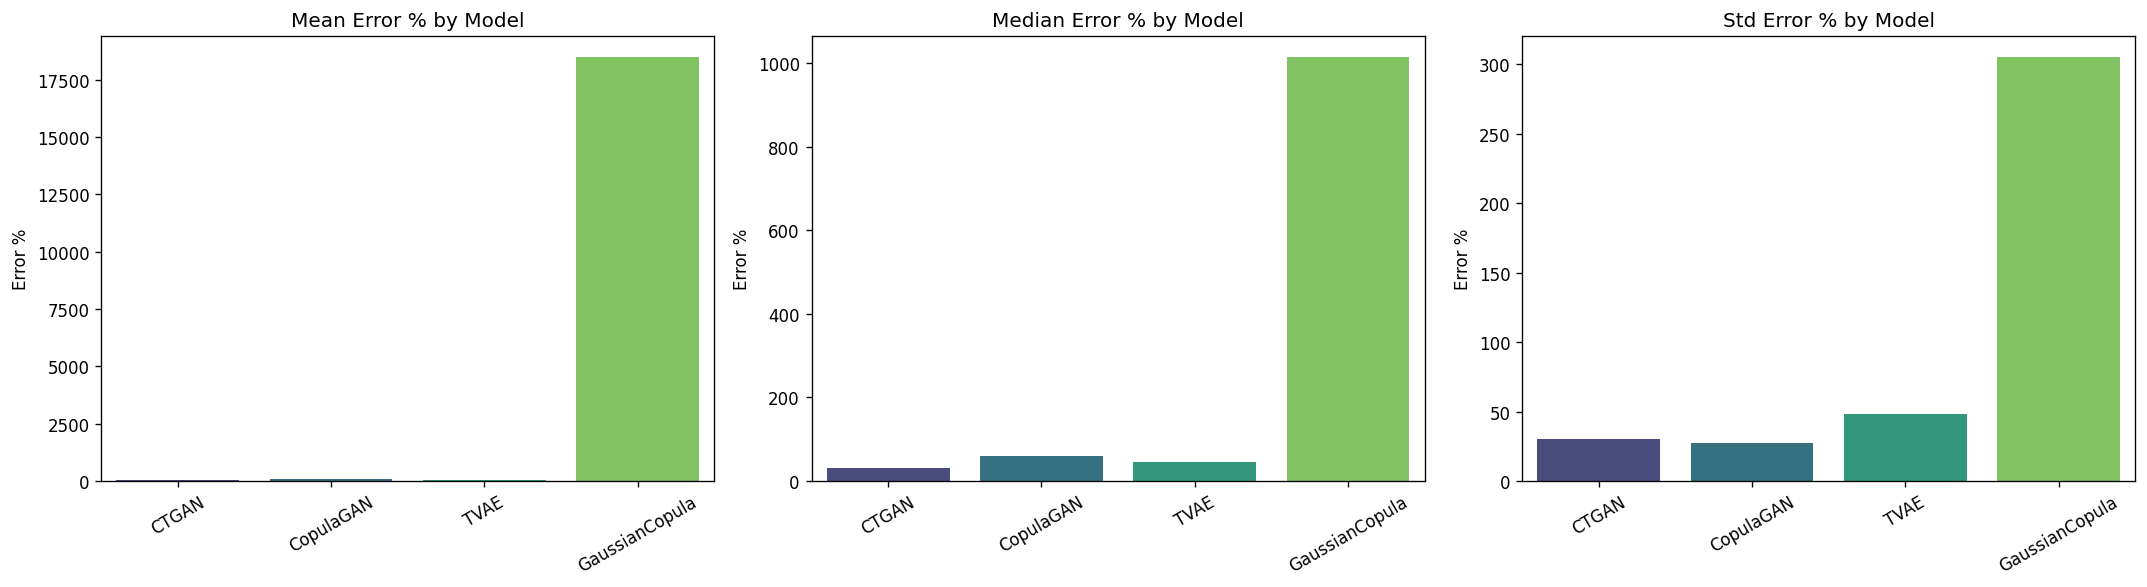

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


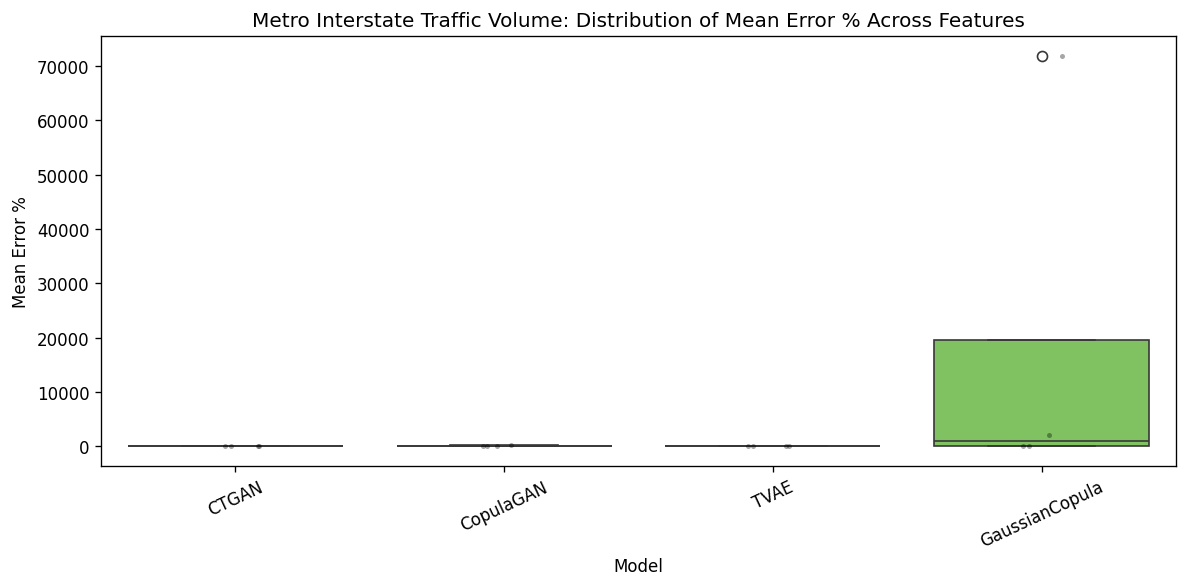

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Metro Interstate Traffic Volume: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

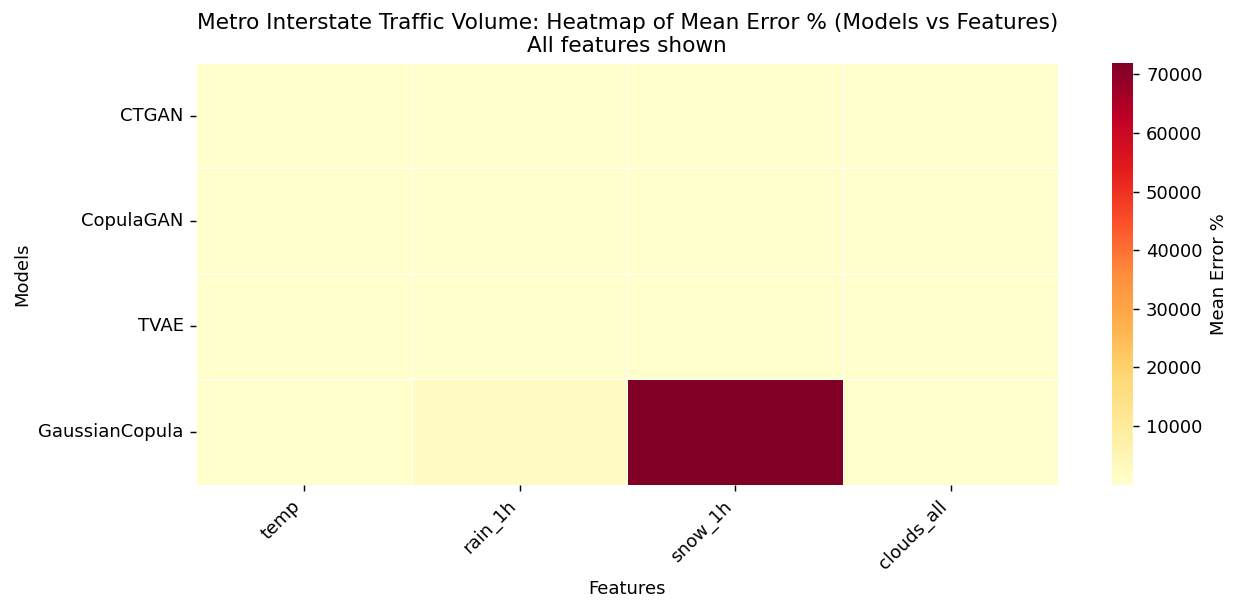

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Metro Interstate Traffic Volume: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [18]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_metro(real_df, synth_df, target="traffic_volume", date_col="date_time"):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target]]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        # Compare each feature's relationship with target using rank correlation difference
        for col in num_cols:
            r_rel = real_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            s_rel = synth_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            results_target.append({
                "feature": col,
                "delta_target_relation": abs(r_rel - s_rel)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = (
        pd.DataFrame(results_target).sort_values("delta_target_relation", ascending=False)
        if results_target else
        pd.DataFrame(columns=["feature", "delta_target_relation"])
    )

    return corr_df, target_df

In [19]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "traffic_volume"
date_col = "date_time"

if "bivariate_quality_metro" in globals():
    quality_fn = bivariate_quality_metro
elif "bivariate_quality_heart" in globals():
    quality_fn = bivariate_quality_heart
elif "bivariate_quality_cancer" in globals():
    quality_fn = bivariate_quality_cancer
else:
    raise NameError("Define `bivariate_quality_metro` (or another quality function) before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_eval = real_df.drop(columns=[date_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[date_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by relation to {target_col}:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next(
        (c for c in ["AbsDiff", "abs_diff", "Difference", "diff", "delta_corr"] if c in corr_results.columns),
        None
    )
    target_metric_col = next(
        (c for c in ["AbsDiff", "abs_diff", "Difference", "diff", "delta_target_relation", "delta_wasserstein"] if c in target_results.columns),
        None
    )

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
2,temp,clouds_all,0.093407
0,temp,rain_1h,0.039620
4,rain_1h,clouds_all,0.033834
1,temp,snow_1h,NaN
3,rain_1h,snow_1h,NaN
5,snow_1h,clouds_all,NaN


CTGAN - Features that differ most by relation to traffic_volume:


,feature,delta_target_relation
3,clouds_all,0.114553
0,temp,0.050544
1,rain_1h,0.011808
2,snow_1h,NaN



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
2,temp,clouds_all,0.060328
4,rain_1h,clouds_all,0.026589
5,snow_1h,clouds_all,0.024473
1,temp,snow_1h,0.018318
3,rain_1h,snow_1h,0.014563
0,temp,rain_1h,0.009430


GaussianCopula - Features that differ most by relation to traffic_volume:


,feature,delta_target_relation
3,clouds_all,0.023533
1,rain_1h,0.017945
0,temp,0.005024
2,snow_1h,0.002916


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.093407,0.055621,0.114553,0.058969
1,CopulaGAN,0.086332,0.030595,0.111390,0.059919
2,TVAE,0.031271,0.019611,0.056039,0.052388
3,GaussianCopula,0.060328,0.025617,0.023533,0.012354


### 3 Multivariate Analysis


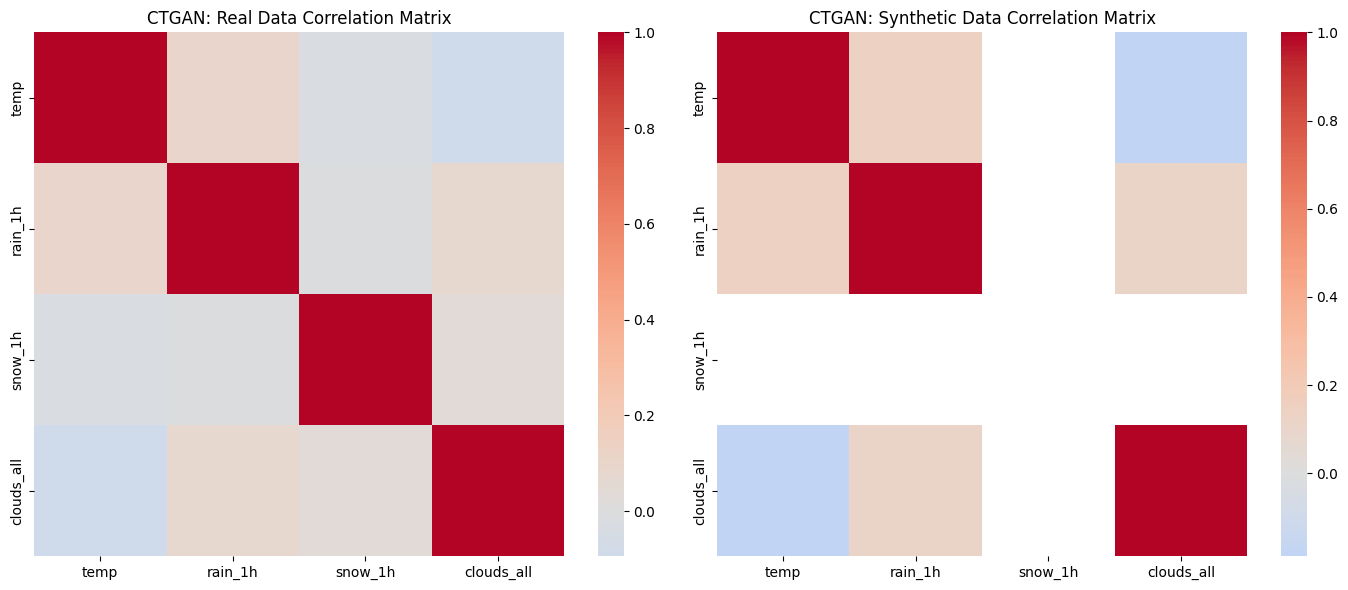

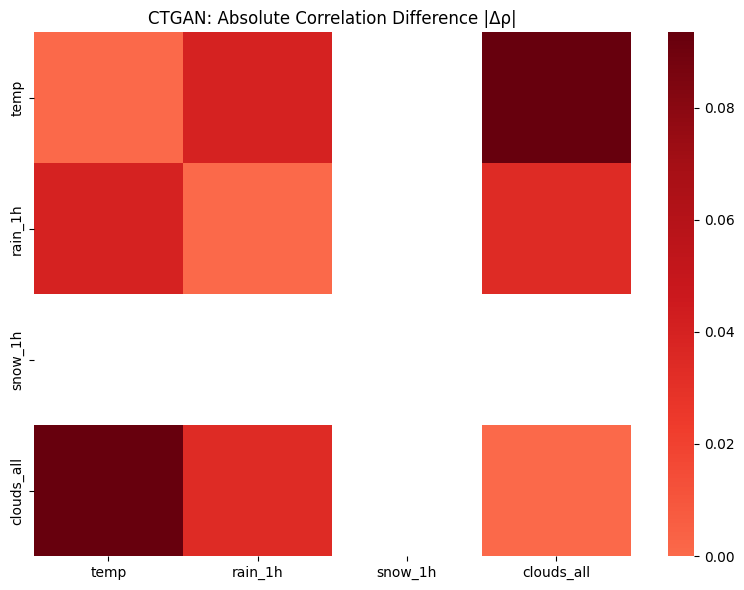

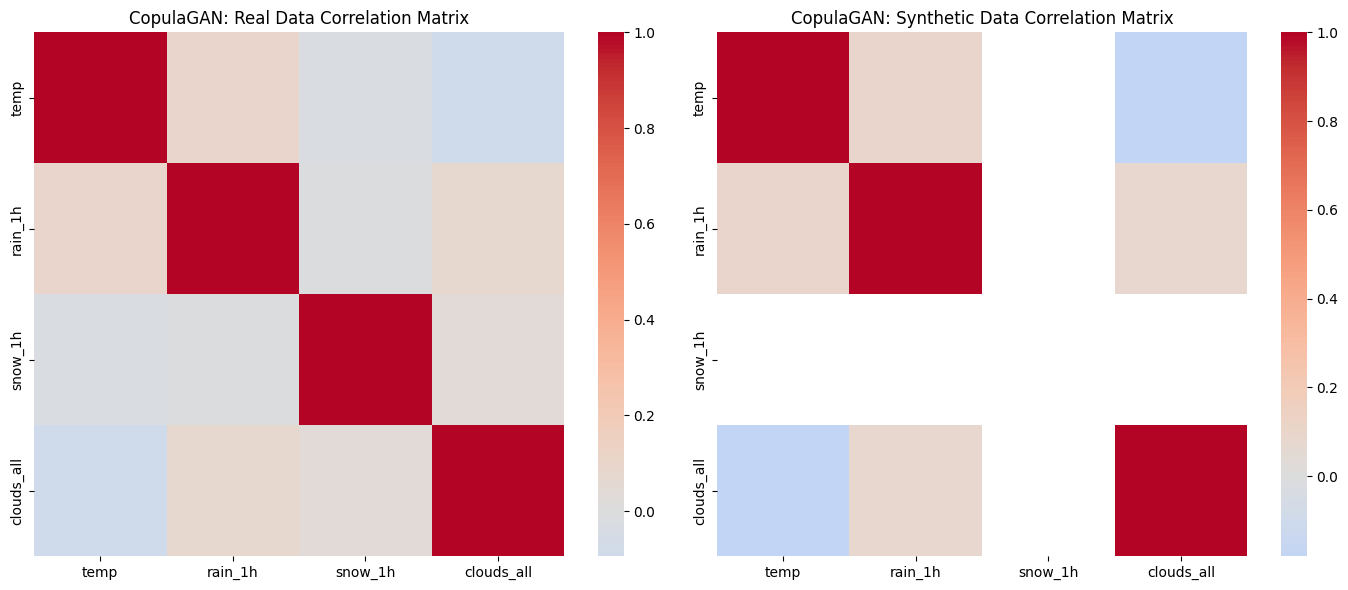

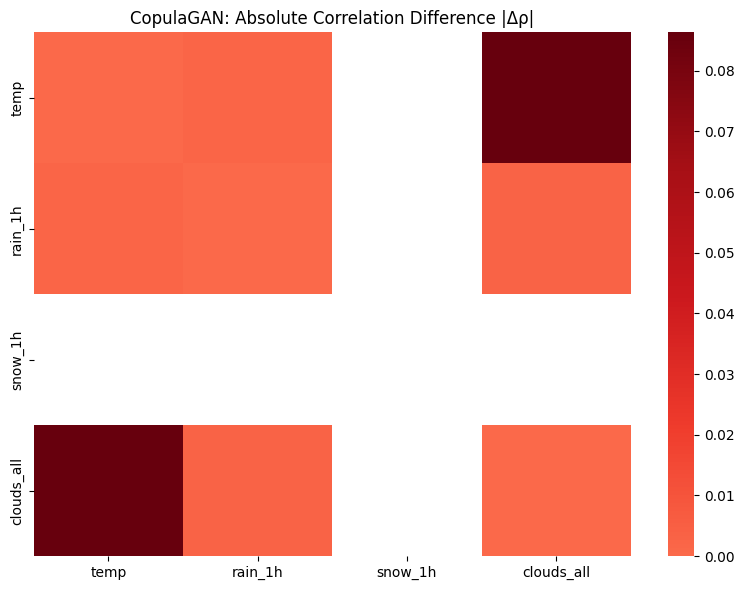

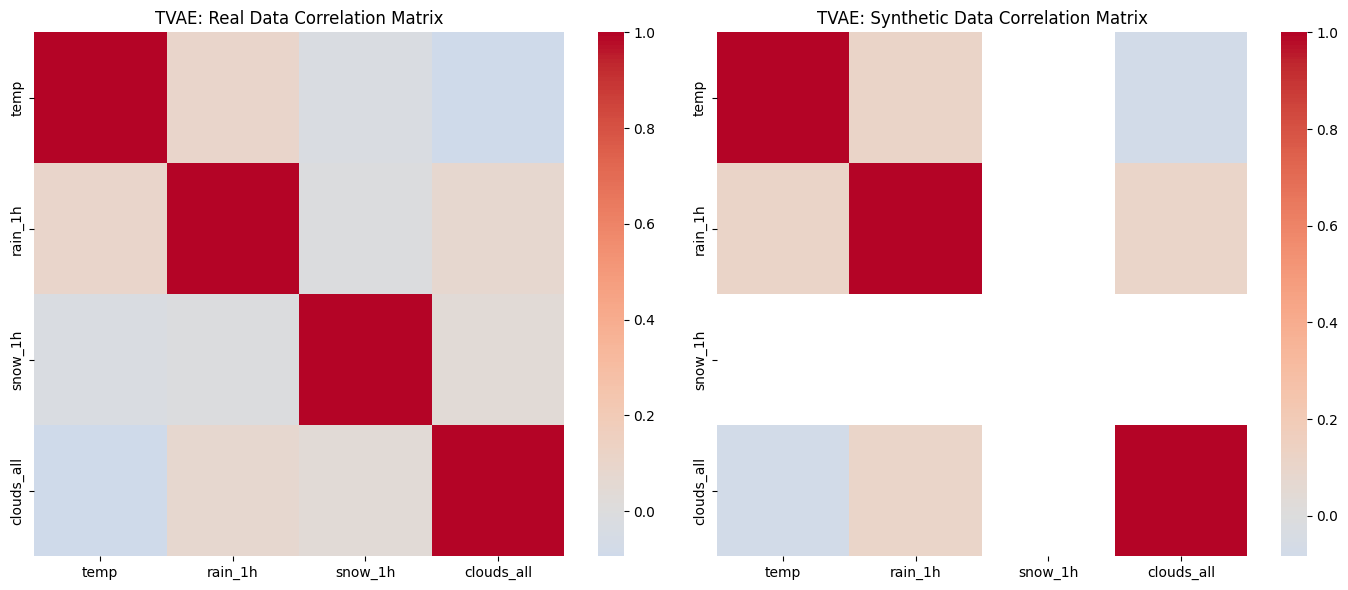

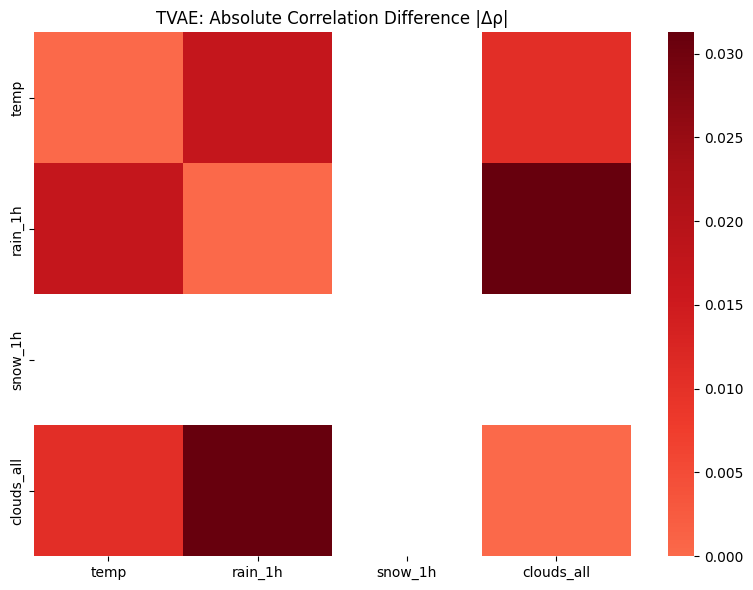

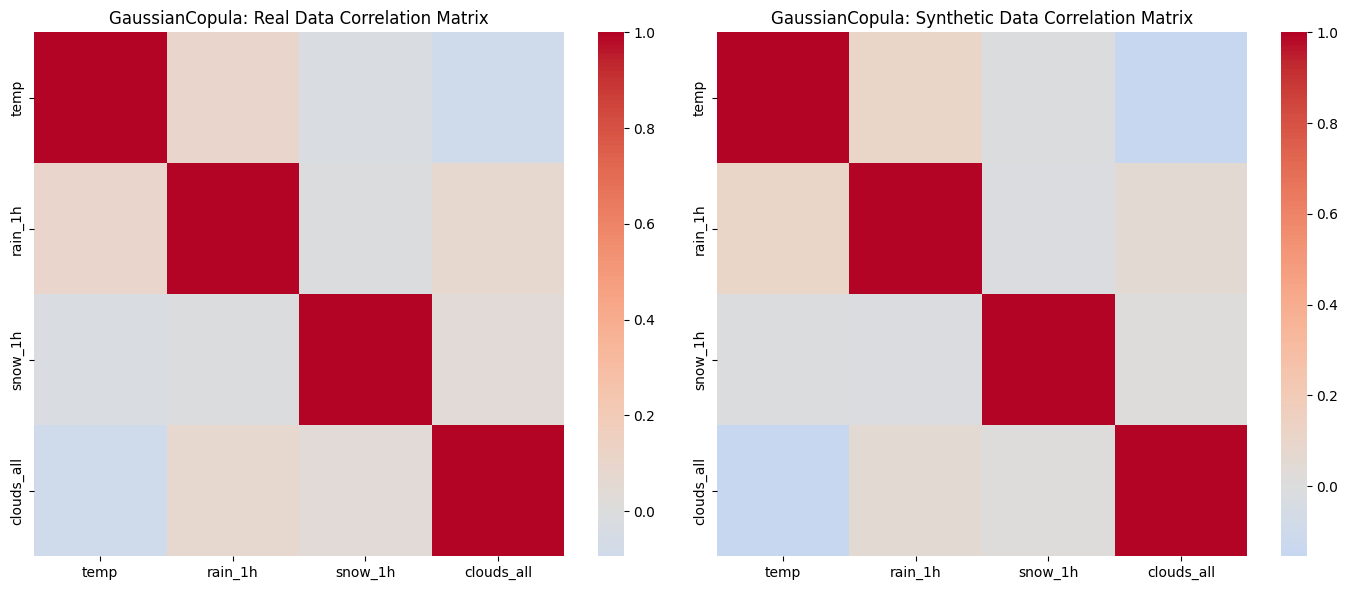

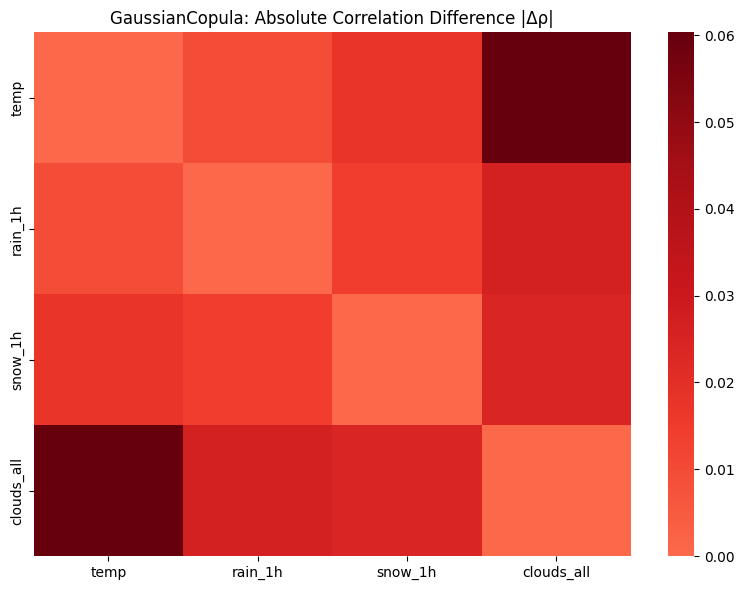

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "traffic_volume"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.010768


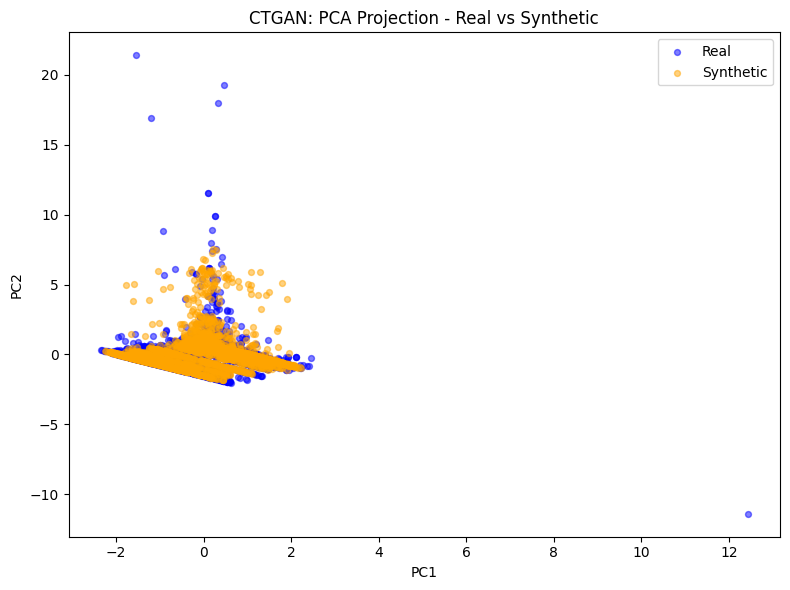

CTGAN - Two-Sample Classifier Accuracy: 0.7690

CopulaGAN - Global MMD (RBF): 0.019700


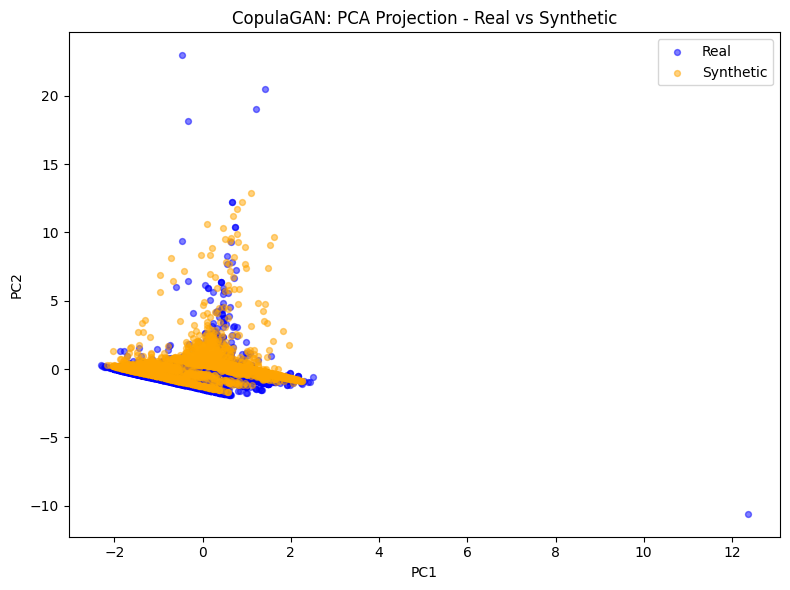

CopulaGAN - Two-Sample Classifier Accuracy: 0.9710

TVAE - Global MMD (RBF): 0.001242


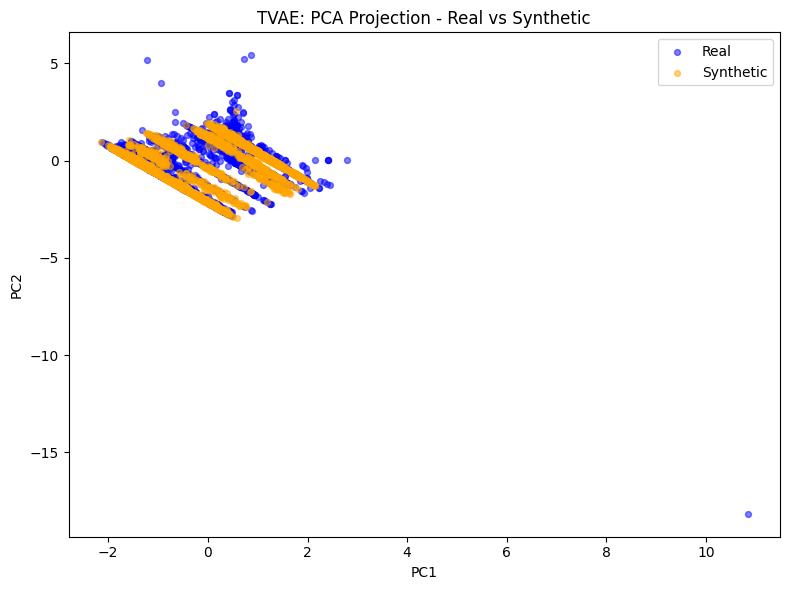

TVAE - Two-Sample Classifier Accuracy: 0.6993

GaussianCopula - Global MMD (RBF): 1.112865


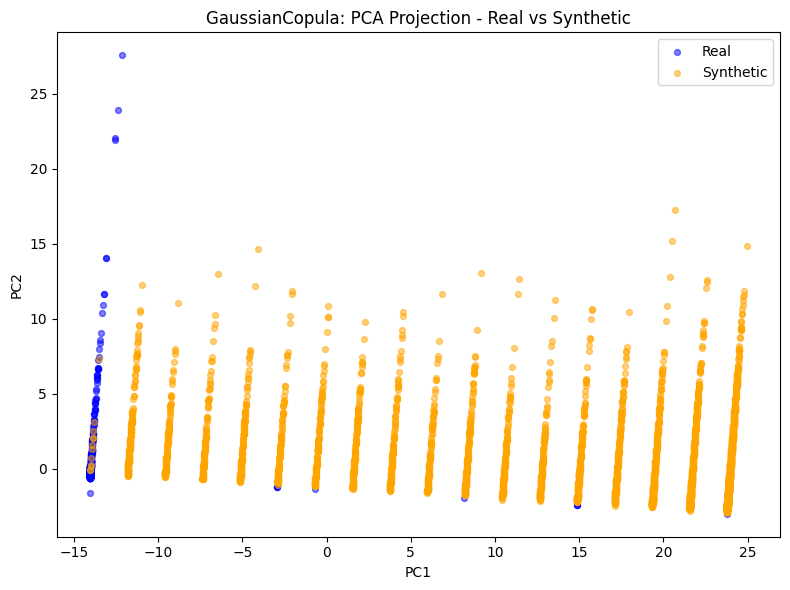

GaussianCopula - Two-Sample Classifier Accuracy: 0.9983

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,TVAE,0.001242,0.699333
1,CTGAN,0.010768,0.769000
2,CopulaGAN,0.019700,0.971000
3,GaussianCopula,1.112865,0.998333


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"
date_col = "date_time"

drop_cols = [c for c in [target_col, date_col] if c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_df = X_real_df.select_dtypes(include=[np.number]).copy()

results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    X_synth_df = X_synth_df.select_dtypes(include=[np.number]).copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regression models 

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()

    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed
    )

    num_cols = X_train.select_dtypes(include=[np.number]).columns

    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


CTGAN - TSTR


,Model,MAE,RMSE,R2
0,SVR-RBF,1756.953206,1986.875922,0.003183
1,GradientBoost,1734.876611,2008.184251,-0.018313
2,ElasticNet,1770.312246,2013.733160,-0.023948
3,Lasso,1777.241300,2036.591652,-0.047326
4,Ridge,1777.349466,2036.912952,-0.047657
5,LinearRegression,1777.356252,2036.936814,-0.047681
6,MLP,1772.168254,2064.632025,-0.076365
7,KNN,1857.310400,2188.098426,-0.208949
8,RandomForest,1847.722400,2230.410018,-0.256156
9,ExtraTrees,1949.072810,2391.757772,-0.444470


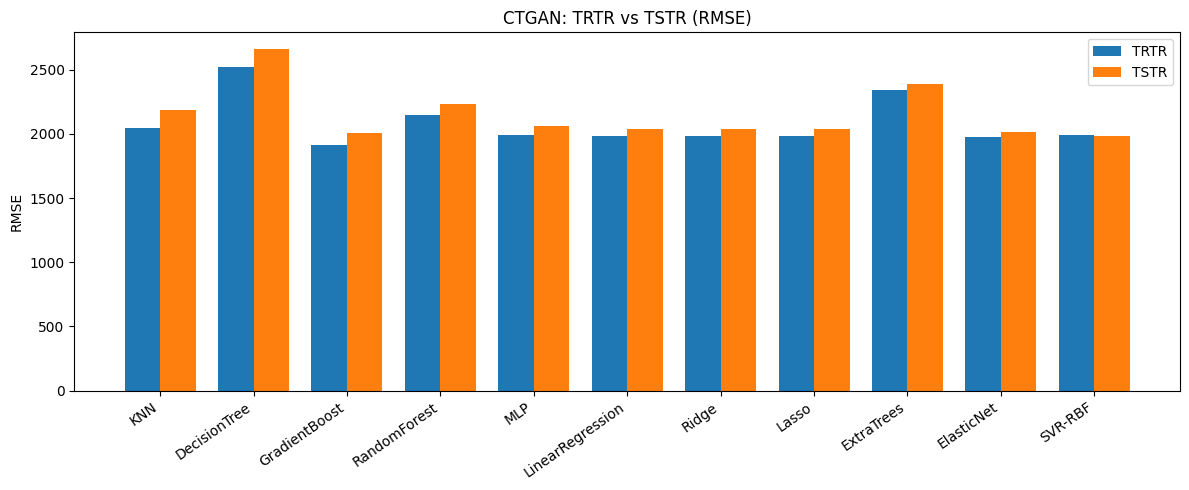

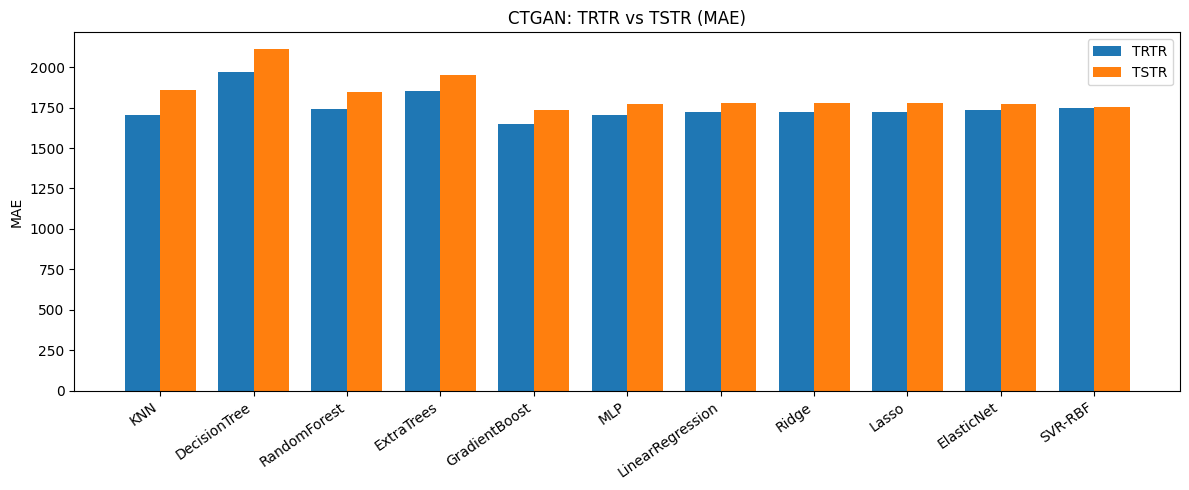

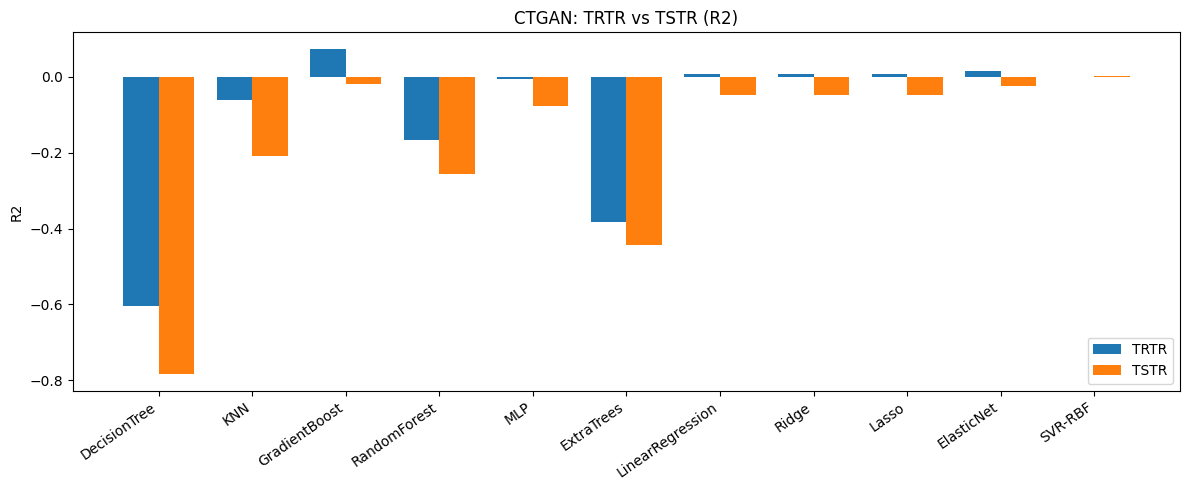

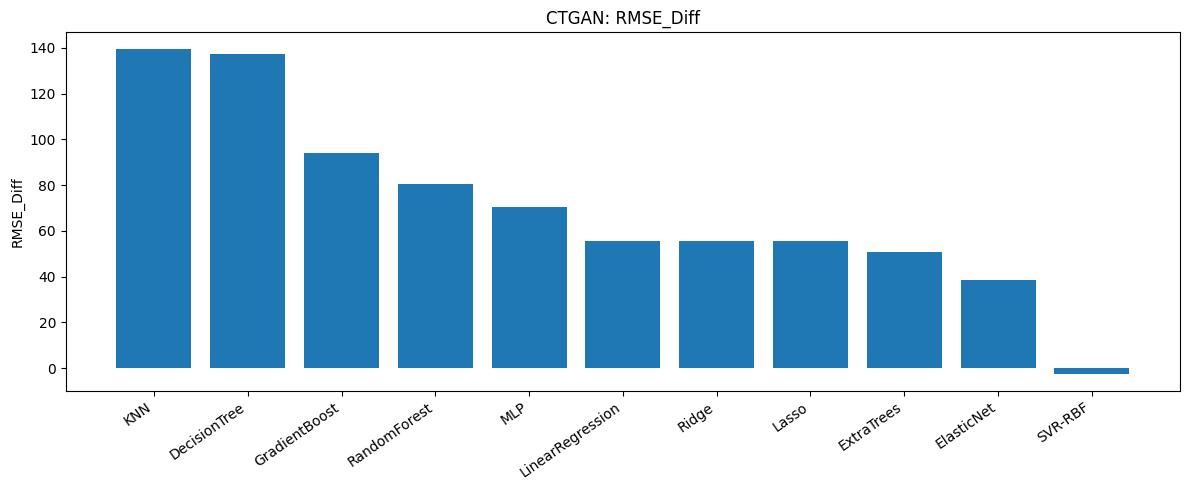

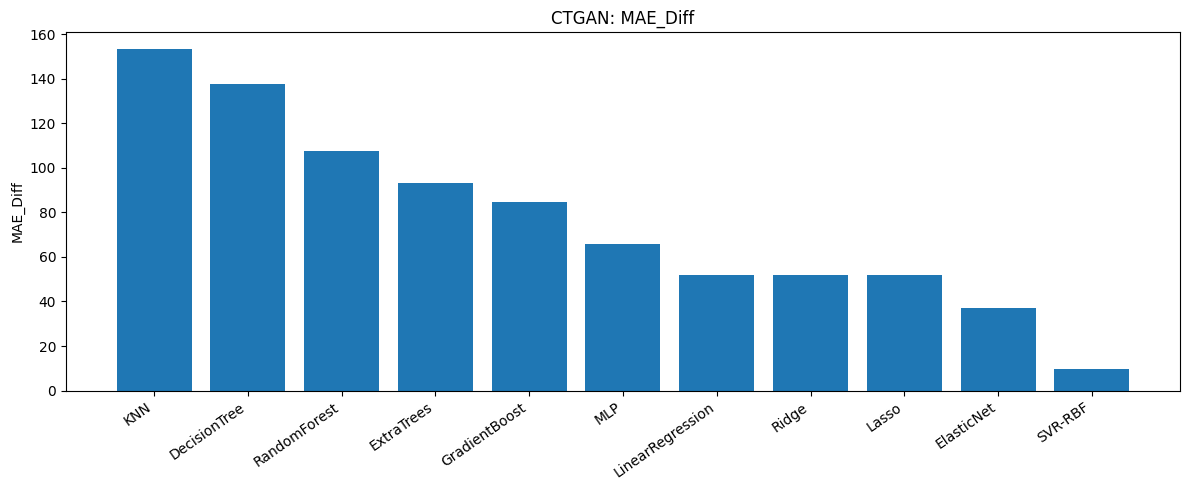

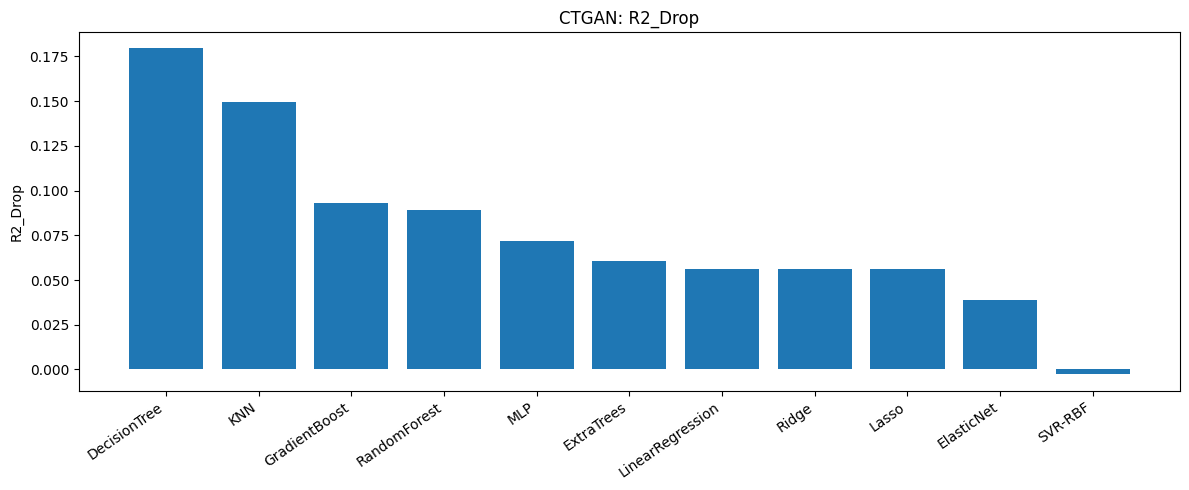


CopulaGAN - TSTR


,Model,MAE,RMSE,R2
0,MLP,1713.453973,1980.796993,0.009273
1,ElasticNet,1727.315974,1985.597521,0.004465
2,Lasso,1719.891320,2005.804626,-0.015901
3,Ridge,1719.871946,2006.061807,-0.016162
4,LinearRegression,1719.869046,2006.088159,-0.016188
5,GradientBoost,1718.475353,2040.098342,-0.050936
6,KNN,1810.682200,2200.645834,-0.222854
7,SVR-RBF,1853.944180,2266.326249,-0.296937
8,RandomForest,1872.404140,2314.243974,-0.352360
9,ExtraTrees,1969.784060,2475.544065,-0.547446


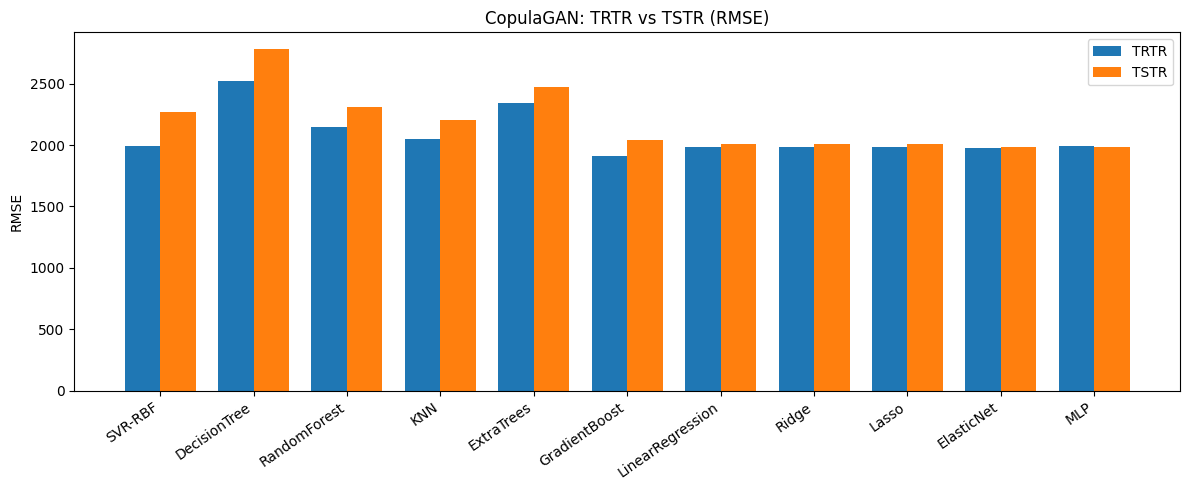

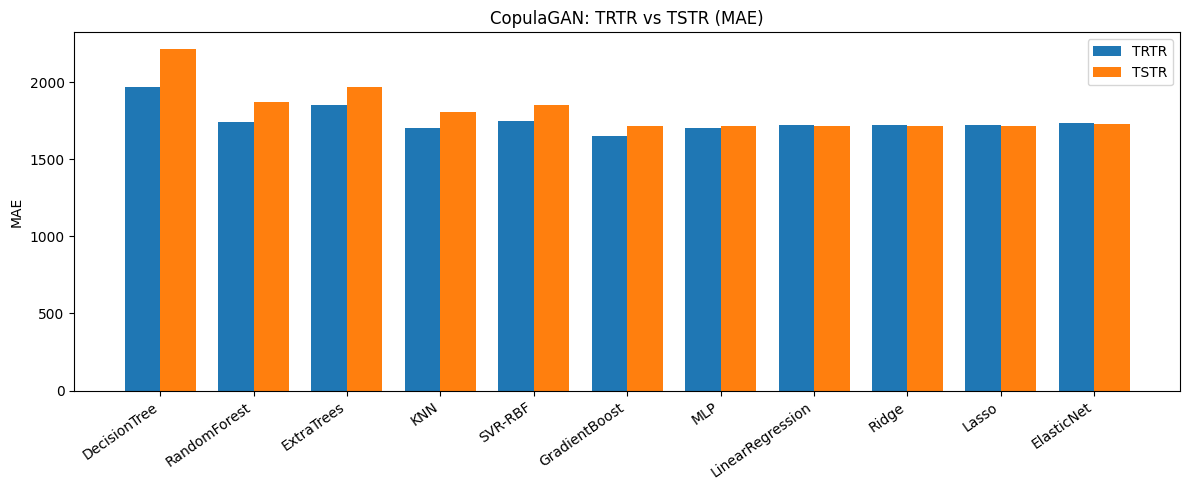

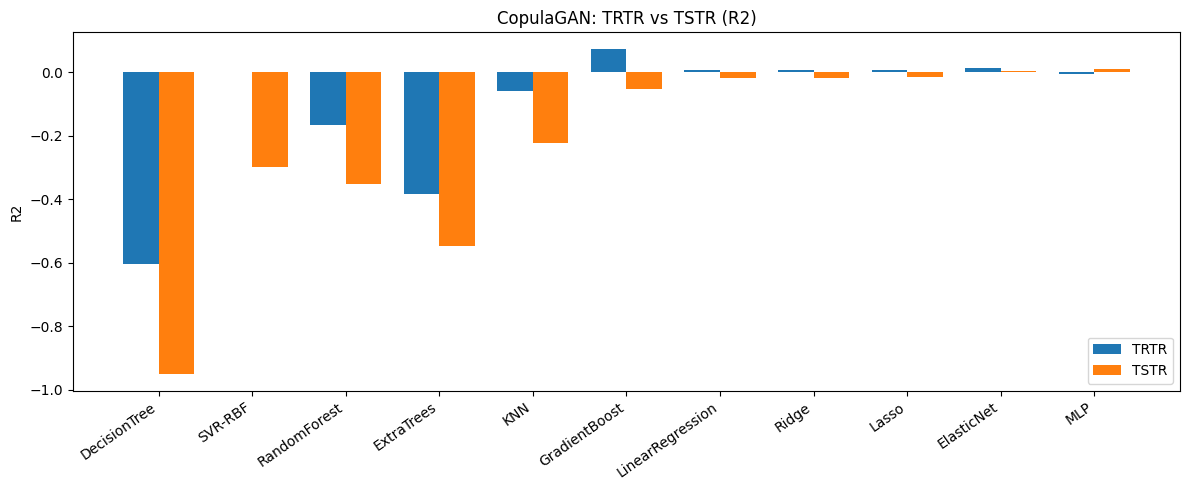

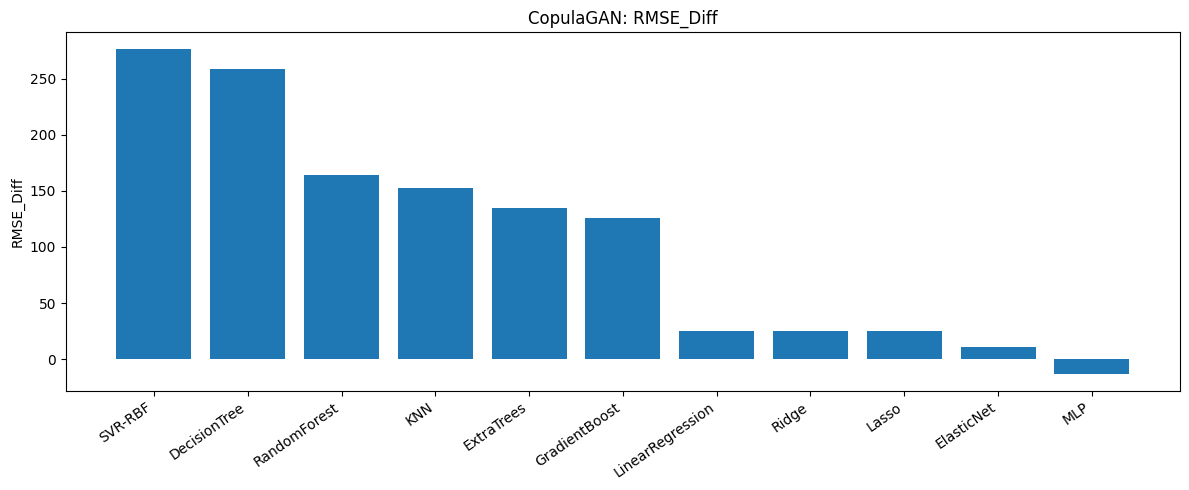

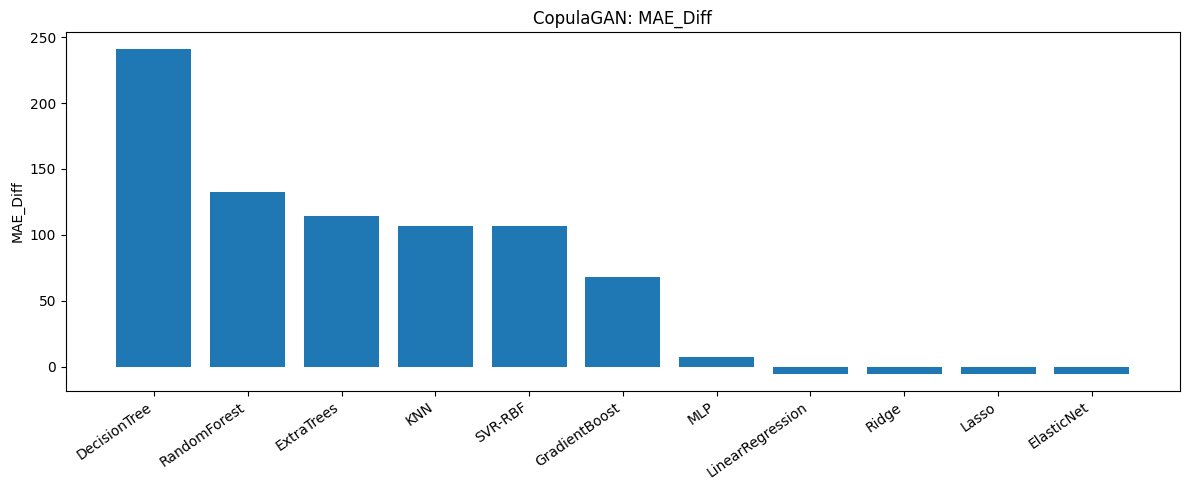

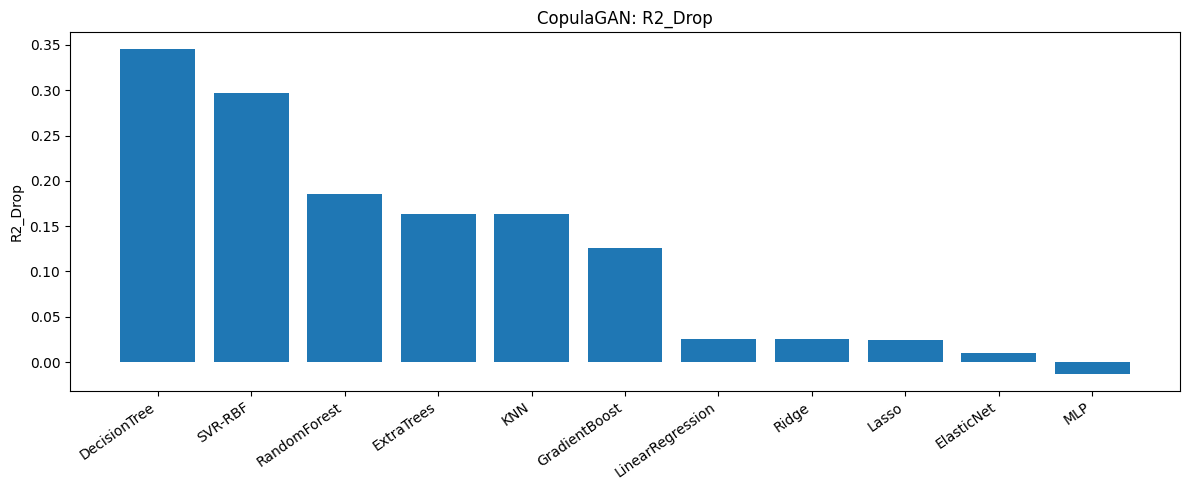


TVAE - TSTR


,Model,MAE,RMSE,R2
0,MLP,1839.617756,2208.421675,-0.231511
1,GradientBoost,1796.171566,2244.649073,-0.272246
2,KNN,1884.559400,2372.975051,-0.421872
3,ElasticNet,1948.589319,2411.549867,-0.468475
4,RandomForest,1919.956190,2463.590215,-0.532537
5,ExtraTrees,1997.946330,2555.780179,-0.649382
6,Lasso,2007.693226,2810.454117,-0.994468
7,Ridge,2008.594504,2816.726936,-1.003381
8,LinearRegression,2008.650774,2817.133421,-1.003960
9,DecisionTree,2209.036000,2823.845657,-1.013520


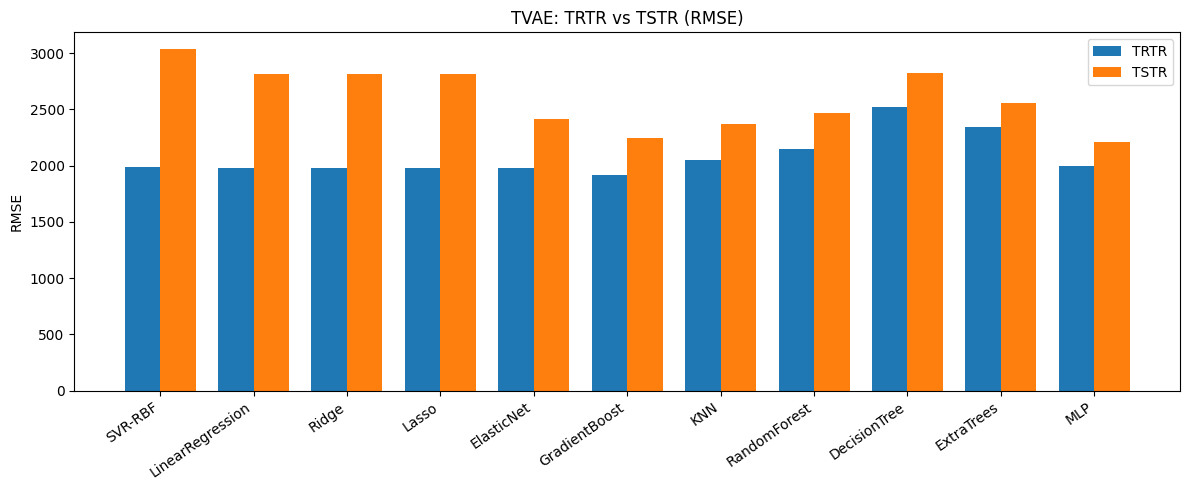

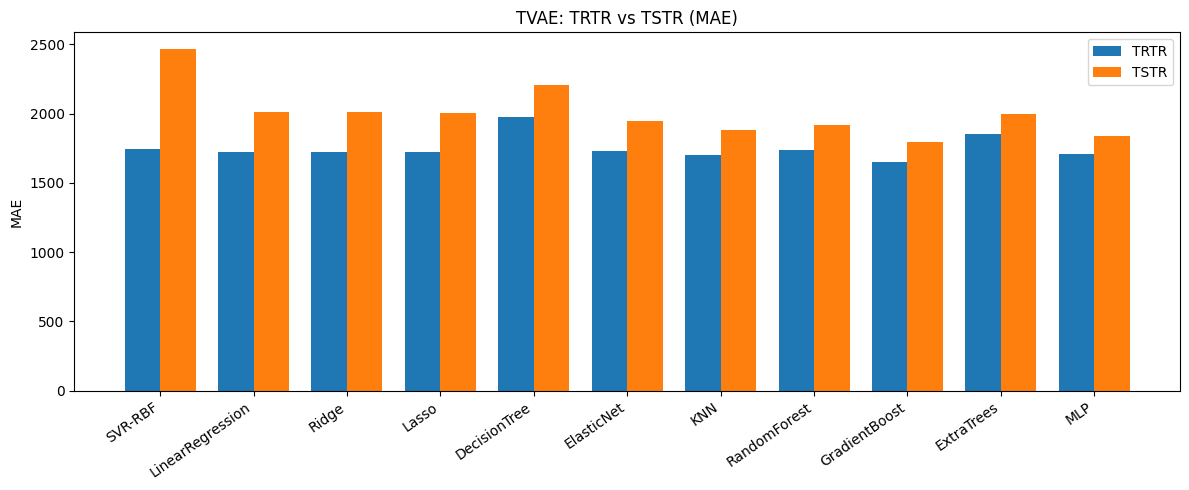

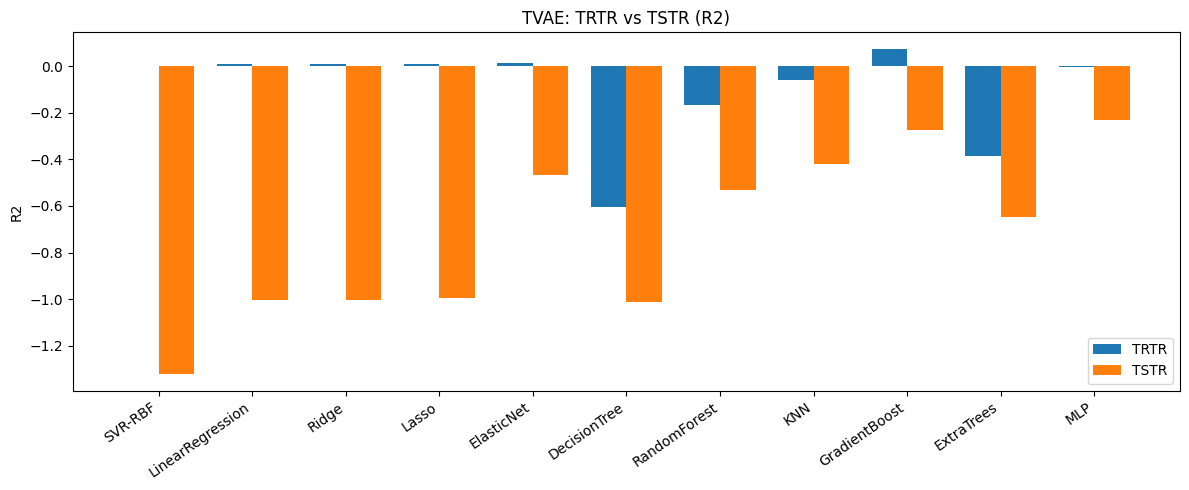

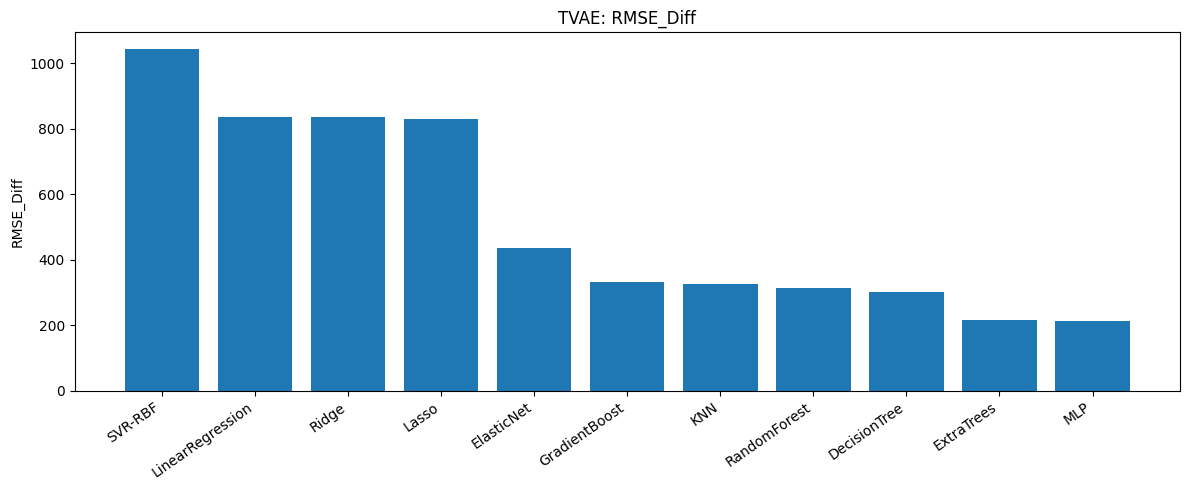

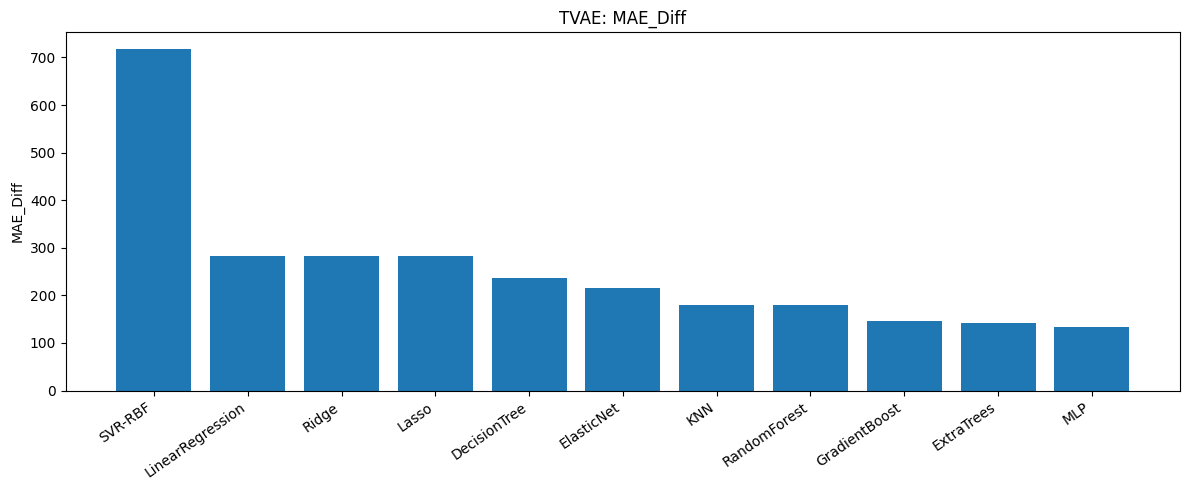

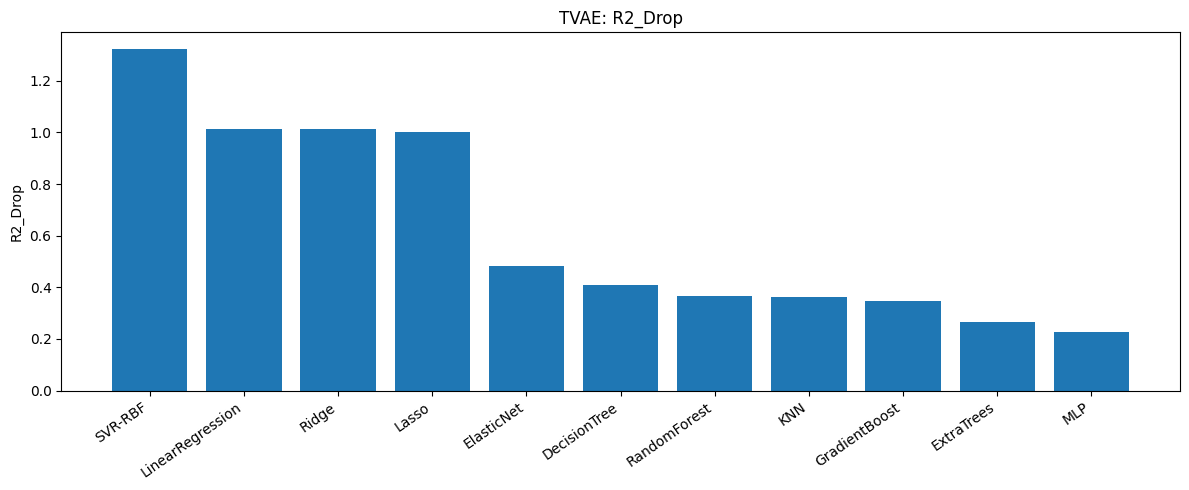


GaussianCopula - TSTR


,Model,MAE,RMSE,R2
0,ElasticNet,1737.329994,1988.245474,0.001808
1,SVR-RBF,1755.908592,1989.042054,0.001008
2,Lasso,1730.357220,1998.247804,-0.008261
3,Ridge,1730.468568,1998.891880,-0.008911
4,LinearRegression,1730.466039,1998.905286,-0.008924
5,MLP,1752.174523,2056.324926,-0.067721
6,GradientBoost,1757.203890,2073.525371,-0.085657
7,RandomForest,1768.212420,2080.538038,-0.093013
8,KNN,1846.792600,2231.410954,-0.257284
9,ExtraTrees,1870.046210,2236.865566,-0.263438


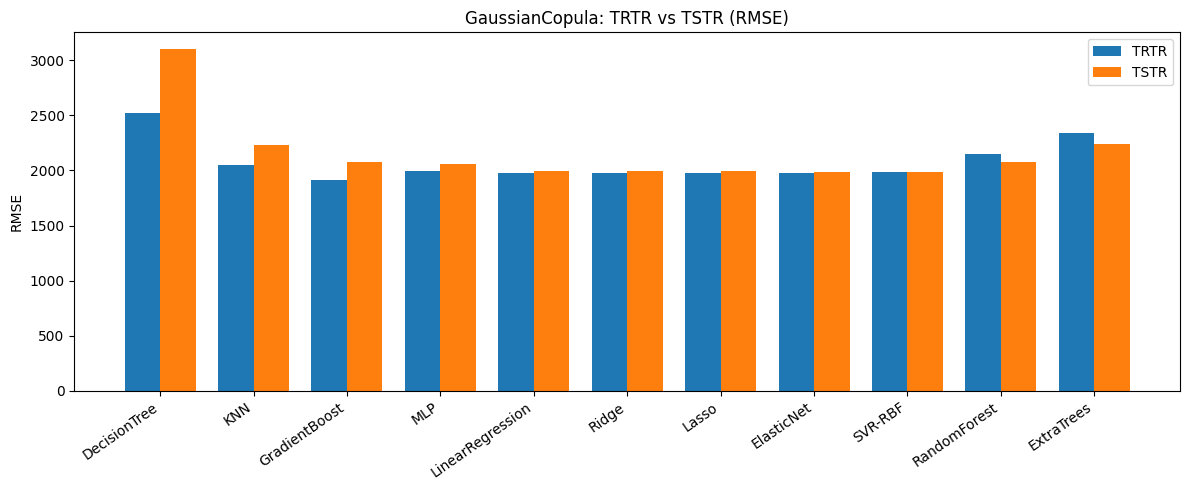

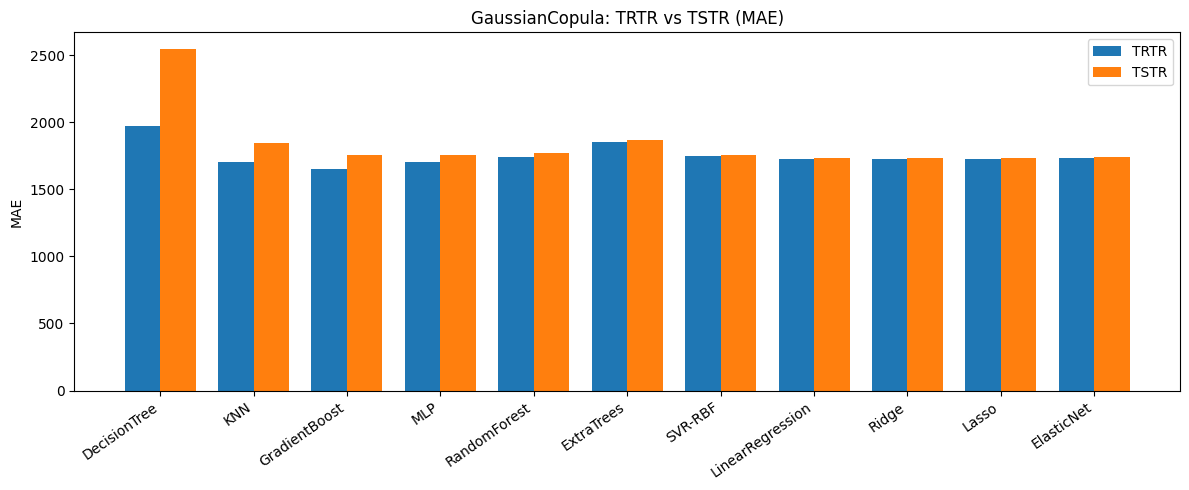

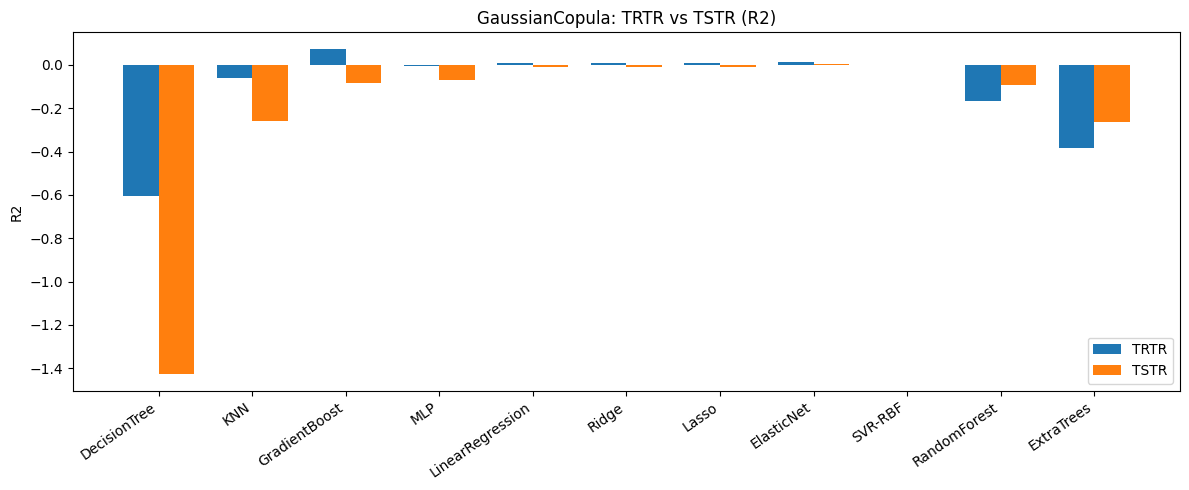

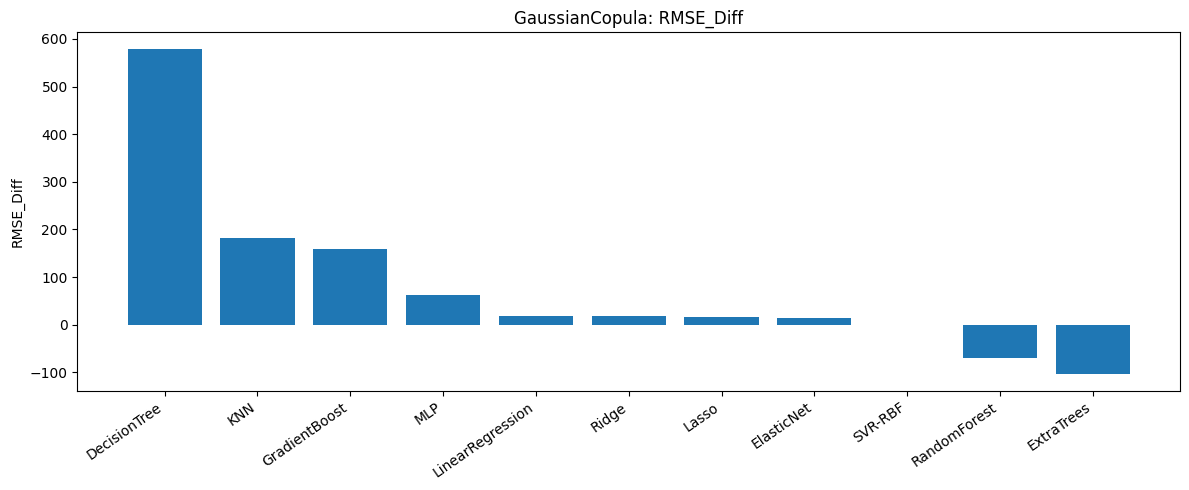

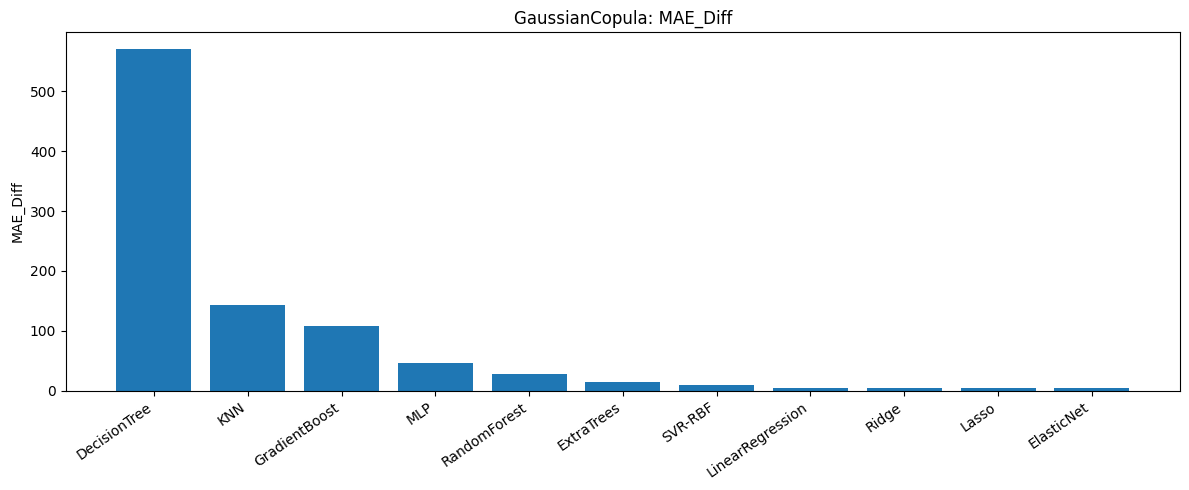

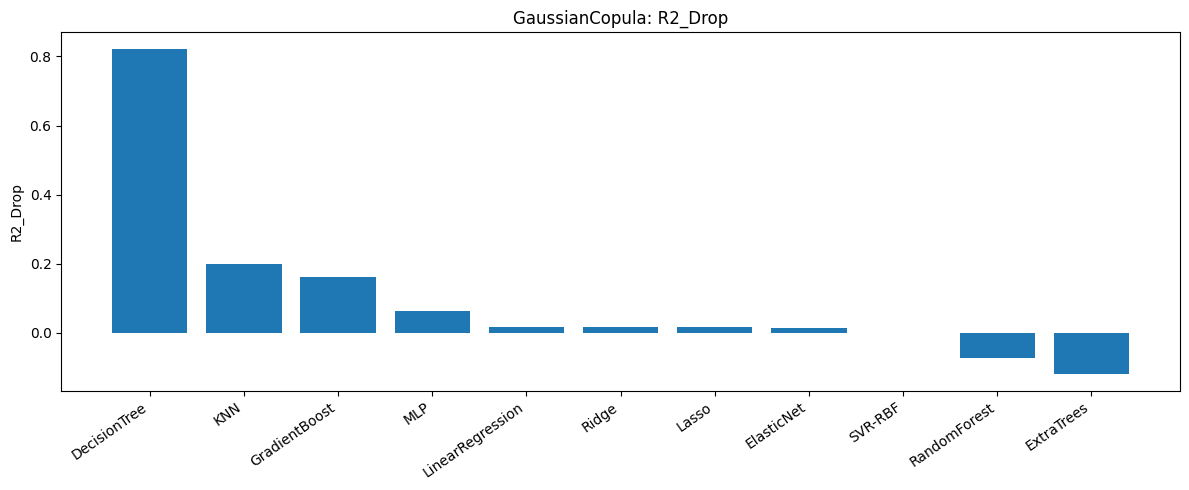


Average metric gap by synthetic generator:


,Synthetic_Model,RMSE_Diff,MAE_Diff,R2_Drop
0,CTGAN,70.477612,76.793917,0.077204
2,GaussianCopula,79.586331,85.055381,0.101380
1,CopulaGAN,107.596988,68.499030,0.123007
3,TVAE,516.420290,254.475854,0.619172


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

label_col = "traffic_volume"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    if metric in ["MAE", "RMSE"]:
        df["Diff"] = df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
    else:
        df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]

    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric}")
    plt.tight_layout()
    plt.show()

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)

    for diff_metric in ["RMSE_Diff", "MAE_Diff", "R2_Drop"]:
        plot_metric_diff(comparison, synth_name, diff_metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_gap = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["RMSE_Diff", "MAE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("\nAverage metric gap by synthetic generator:")
display(summary_gap)


In [25]:
import time
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

label_col = "traffic_volume"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def pick_10_models(models_dict):
    keys = list(models_dict.keys())
    if len(keys) < 10:
        raise ValueError(f"`models` has only {len(keys)} models; need at least 10.")
    return {k: clone(models_dict[k]) for k in keys[:10]}

def run_reg_models(X_train, y_train, X_test, y_test, models_dict):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, reg in models_dict.items():
        t0 = time.time()
        m = clone(reg)
        m.fit(X_train_s, y_train)
        y_pred = m.predict(X_test_s)

        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "FitSec": round(time.time() - t0, 3),
        })
    return pd.DataFrame(rows)

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

X_real = data[feature_cols].to_numpy(dtype=np.float32)
y_real = data[label_col].to_numpy(dtype=np.float32)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

models_used = pick_10_models(models)
print(f"Using {len(models_used)} models: {list(models_used.keys())}")

trtr_results = run_reg_models(
    X_train_real, y_train_real, X_test_real, y_test_real, models_used
)

all_comparisons = []

for synth_name in model_order:
    synth_df = synthetic_datasets[synth_name][data.columns].copy()

    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float32)
    y_synth = synth_df[label_col].to_numpy(dtype=np.float32)

    tstr_results = run_reg_models(
        X_synth, y_synth, X_test_real, y_test_real, models_used
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["MAE_Diff", "RMSE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("Average performance gap by synthetic generator (lower is better):")
display(summary)

print("\nPer-model timing (seconds):")
timing_cols = [c for c in combined_comparison.columns if "FitSec" in c]
display(
    combined_comparison[
        ["Synthetic_Model", "Model"] + timing_cols
    ].sort_values(timing_cols[-1], ascending=False)
)

Using 10 models: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'SVR-RBF', 'KNN', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoost']
Average performance gap by synthetic generator (lower is better):


,Synthetic_Model,MAE_Diff,RMSE_Diff,R2_Drop
0,CTGAN,81.728953,73.281220,0.081683
2,GaussianCopula,89.500867,76.370482,0.102953
1,CopulaGAN,61.973023,102.478987,0.115822
3,TVAE,277.643908,584.123469,0.711015



Per-model timing (seconds):


,Synthetic_Model,Model,FitSec_TRTR,FitSec_TSTR
37,GaussianCopula,RandomForest,0.642,1.389
7,CTGAN,RandomForest,0.642,1.023
24,TVAE,SVR-RBF,0.508,0.987
17,CopulaGAN,RandomForest,0.642,0.986
34,GaussianCopula,SVR-RBF,0.508,0.958
14,CopulaGAN,SVR-RBF,0.508,0.910
4,CTGAN,SVR-RBF,0.508,0.815
27,TVAE,RandomForest,0.642,0.809
38,GaussianCopula,ExtraTrees,0.383,0.626
8,CTGAN,ExtraTrees,0.383,0.519


In [26]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

label_col = "traffic_volume"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def get_preprocessor(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

def evaluate(df_train, df_test, models):
    df_train = df_train.copy()
    df_test = df_test.copy()

    X_train = df_train.drop(columns=[label_col])
    y_train = df_train[label_col].astype(float)

    X_test = df_test.drop(columns=[label_col])
    y_test = df_test[label_col].astype(float)

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    # FIX: make categorical columns all strings
    for c in cat_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    pre = get_preprocessor(X_train)

    results = []
    for name, model in models.items():
        pipe = Pipeline([("prep", pre), ("model", clone(model))])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        results.append({
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        })

    return pd.DataFrame(results).sort_values("RMSE")

# TRTR
trtr = evaluate(data, data, models)
print("TRTR Results")
display(trtr)

all_results = []

for synth in model_order:
    synth_df = synthetic_datasets[synth][data.columns]

    tstr = evaluate(synth_df, data, models)
    print(f"\n{synth} - TSTR")
    display(tstr)

    comp = trtr.merge(tstr, on="Model", suffixes=("_TRTR", "_TSTR"))
    comp["RMSE_Diff"] = comp["RMSE_TSTR"] - comp["RMSE_TRTR"]
    comp["R2_Drop"] = comp["R2_TRTR"] - comp["R2_TSTR"]
    comp["Synthetic"] = synth

    all_results.append(comp)

summary = (
    pd.concat(all_results)
    .groupby("Synthetic")[["RMSE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("\nSummary (lower RMSE_Diff better)")
display(summary)

TRTR Results


,Model,RMSE,MAE,R2
6,DecisionTree,0.000000,0.000000,1.000000
8,ExtraTrees,0.000000,0.000000,1.000000
0,LinearRegression,0.956315,0.228391,1.000000
10,MLP,3.071727,1.366658,0.999998
7,RandomForest,790.853458,623.291494,0.841886
1,Ridge,957.752686,826.957833,0.768108
5,KNN,1690.910778,1402.579440,0.277196
9,GradientBoost,1860.987237,1621.197202,0.124480
2,Lasso,1931.471133,1674.013030,0.056904
3,ElasticNet,1957.055807,1710.469000,0.031754



CTGAN - TSTR


,Model,RMSE,MAE,R2
4,SVR-RBF,1991.506651,1748.398058,-0.002635
9,GradientBoost,2004.548189,1728.545671,-0.015810
3,ElasticNet,2014.394180,1755.376005,-0.025813
2,Lasso,2018.979259,1738.526036,-0.030488
1,Ridge,2023.338420,1740.344732,-0.034943
5,KNN,2157.721095,1806.576840,-0.176982
7,RandomForest,2265.481360,1817.551334,-0.297479
10,MLP,2298.420027,1897.394096,-0.335482
8,ExtraTrees,2522.034494,1972.233662,-0.607982
6,DecisionTree,2682.058049,2104.012200,-0.818510



CopulaGAN - TSTR


...

,Model,RMSE,MAE,R2
3,ElasticNet,2326.622314,1926.274249,-0.368457
9,GradientBoost,2339.310237,1874.922567,-0.383423
10,MLP,2368.429521,1930.731298,-0.418078
2,Lasso,2515.488604,1998.191293,-0.599646
1,Ridge,2524.305849,2001.166932,-0.610880
5,KNN,2540.495583,2023.292760,-0.631609
7,RandomForest,2671.418797,2082.694564,-0.804111
8,ExtraTrees,2764.824393,2158.991174,-0.932477
6,DecisionTree,2856.538843,2224.856600,-1.062811
4,SVR-RBF,3082.469739,2522.302305,-1.402022



GaussianCopula - TSTR


,Model,RMSE,MAE,R2
3,ElasticNet,1976.811368,1719.715233,0.012107
9,GradientBoost,1977.010564,1716.541361,0.011908
4,SVR-RBF,1986.656256,1741.829042,0.002243
2,Lasso,1987.982983,1712.970472,0.000910
1,Ridge,1991.447089,1714.135627,-0.002575
0,LinearRegression,1992.815738,1714.948768,-0.003953
7,RandomForest,2002.280949,1721.935318,-0.013513
10,MLP,2010.285015,1738.229546,-0.021632
8,ExtraTrees,2142.375038,1789.308720,-0.160300
5,KNN,2301.203284,1910.137760,-0.338718



Summary (lower RMSE_Diff better)


,RMSE_Diff,R2_Drop
Synthetic,,
GaussianCopula,1092.401888,0.694089
CopulaGAN,1208.665245,0.824319
CTGAN,1237.619110,0.859106
TVAE,1640.904505,1.360611


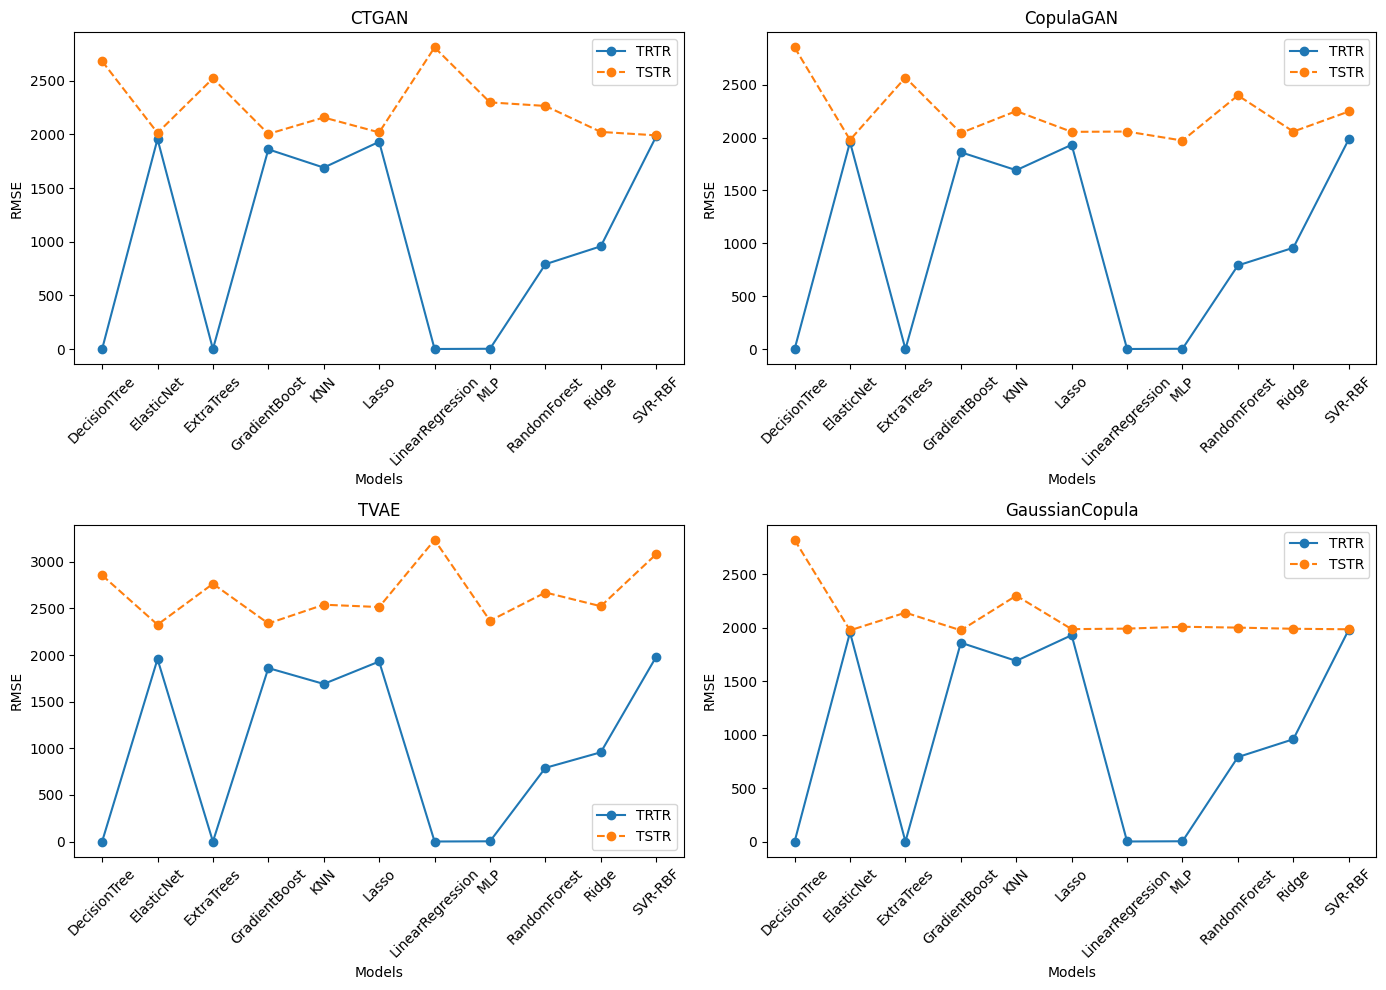

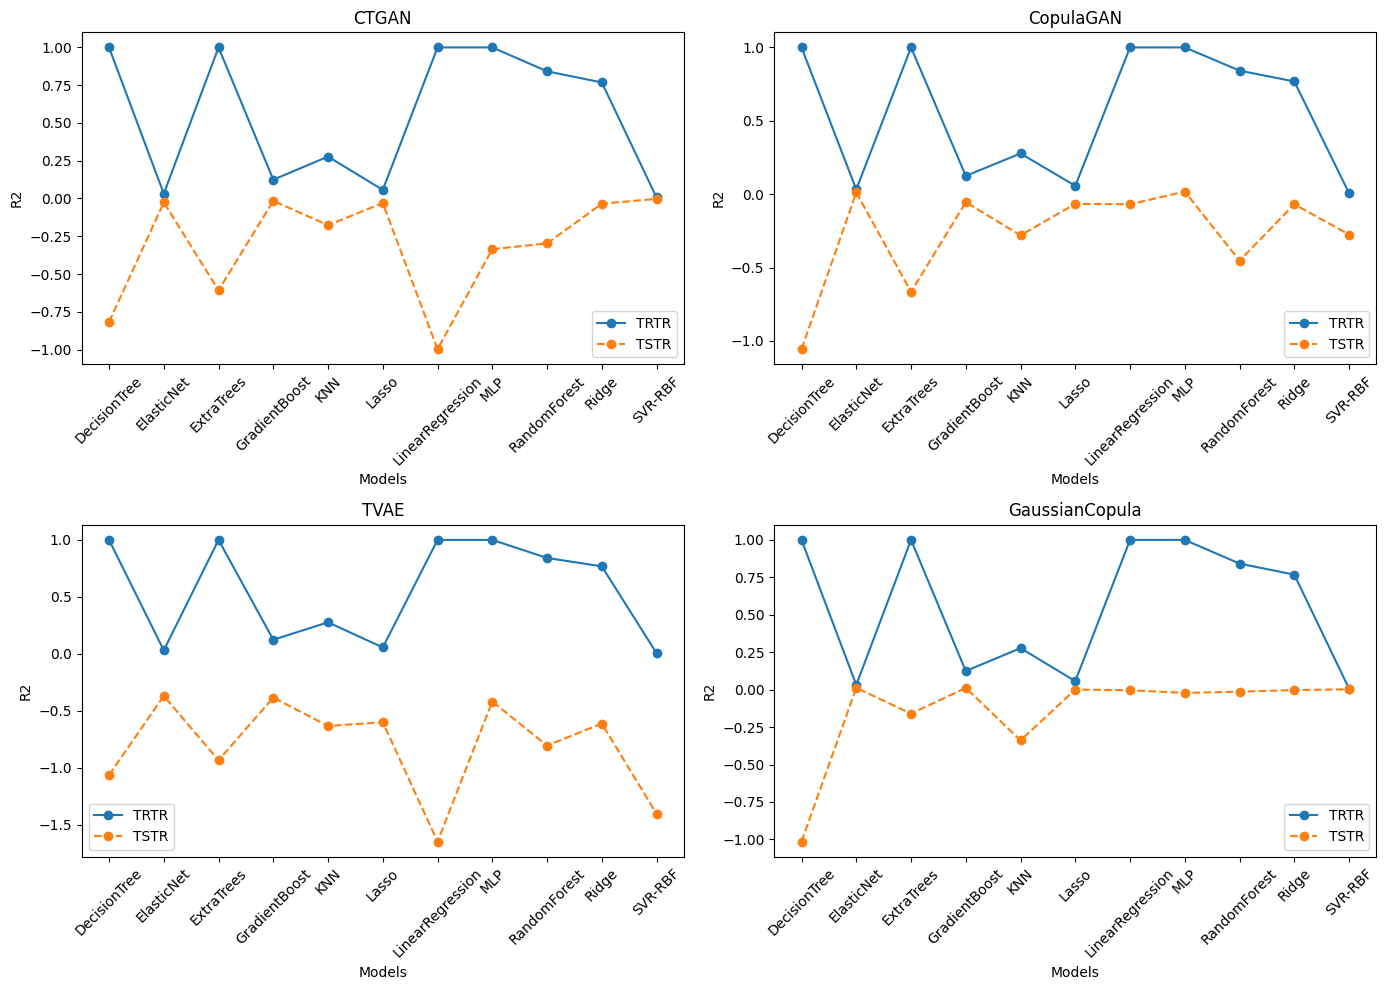

In [41]:
import matplotlib.pyplot as plt

final_df = pd.concat(all_results, ignore_index=True)

gen_models = final_df["Synthetic"].unique()

# -------- RMSE Subplots --------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, gen in enumerate(gen_models):
    subset = final_df[final_df["Synthetic"] == gen].sort_values("Model")
    x = range(len(subset["Model"]))

    axes[i].plot(x, subset["RMSE_TRTR"], marker='o', label="TRTR")
    axes[i].plot(x, subset["RMSE_TSTR"], marker='o', linestyle='--', label="TSTR")

    axes[i].set_title(gen)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(subset["Model"], rotation=45)
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()

plt.tight_layout()
plt.show()

# -------- R2 Subplots --------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, gen in enumerate(gen_models):
    subset = final_df[final_df["Synthetic"] == gen].sort_values("Model")
    x = range(len(subset["Model"]))

    axes[i].plot(x, subset["R2_TRTR"], marker='o', label="TRTR")
    axes[i].plot(x, subset["R2_TSTR"], marker='o', linestyle='--', label="TSTR")

    axes[i].set_title(gen)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(subset["Model"], rotation=45)
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel("R2")
    axes[i].legend()

plt.tight_layout()
plt.show()

# 5 Statistical similarity tests 

Average feature-distribution error by model (Metro Interstate Traffic Volume)


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,40.048378,29.994905,30.509367
1,CopulaGAN,81.279423,59.855033,27.611034
2,TVAE,47.241577,44.337077,48.197771
3,GaussianCopula,18489.511373,1014.043406,305.255893


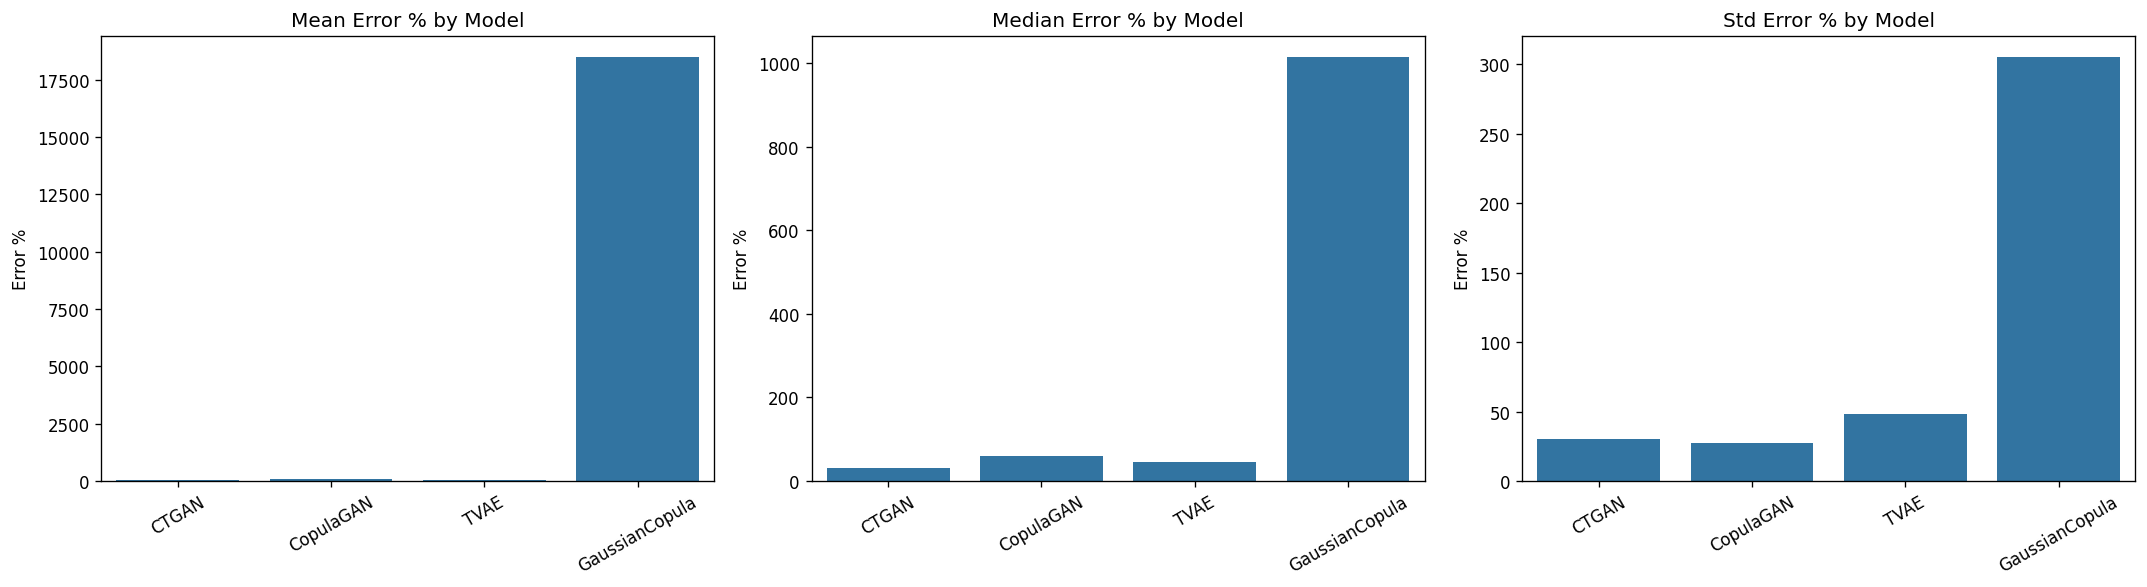

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

real_df = data.copy()

exclude_cols = {target_col}
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_num = real_df[num_cols].astype(np.float64)
    synth_num = synth_df[num_cols].astype(np.float64)

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    })

    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average feature-distribution error by model (Metro Interstate Traffic Volume)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0])
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1])
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2])
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


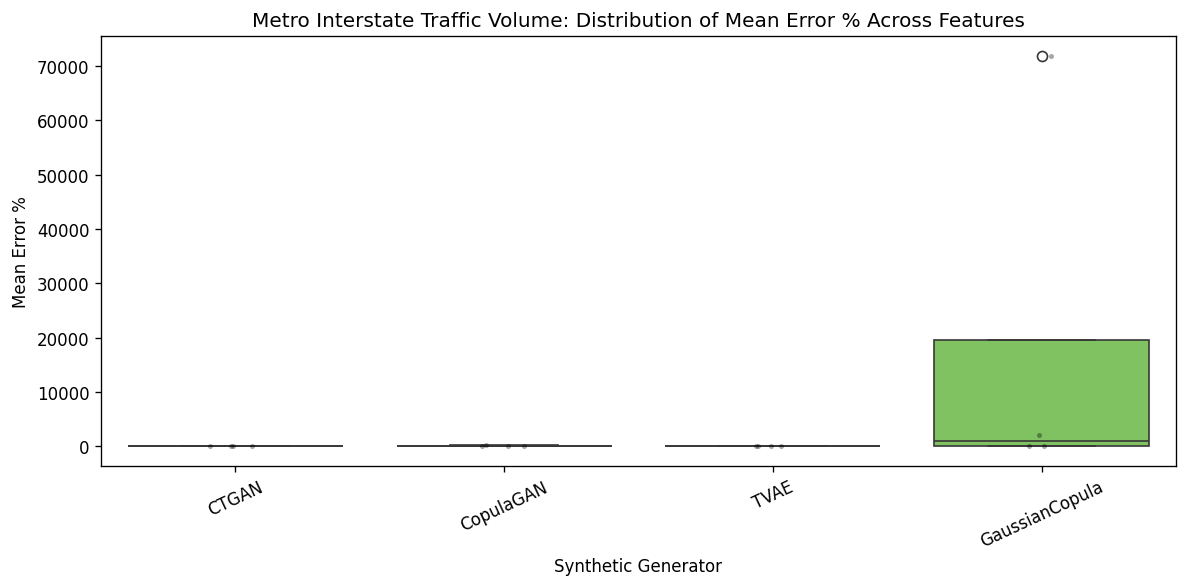

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", order=model_order, palette="viridis")
sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    order=model_order,
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Metro Interstate Traffic Volume: Distribution of Mean Error % Across Features")
plt.xlabel("Synthetic Generator")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

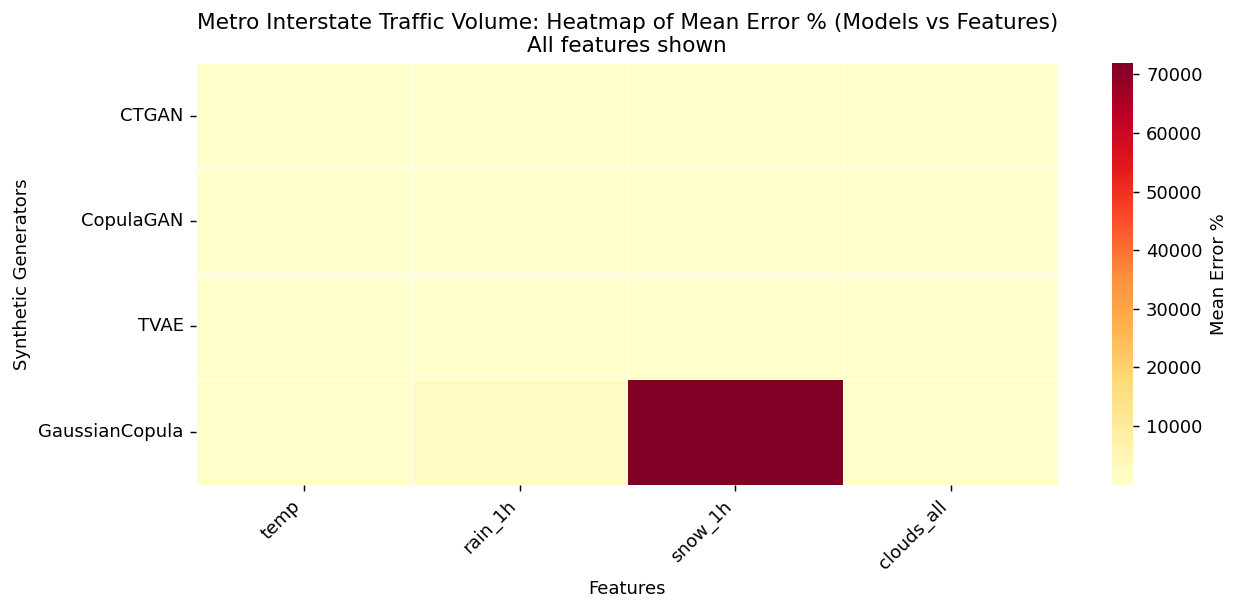

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df.mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Metro Interstate Traffic Volume: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Synthetic Generators")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

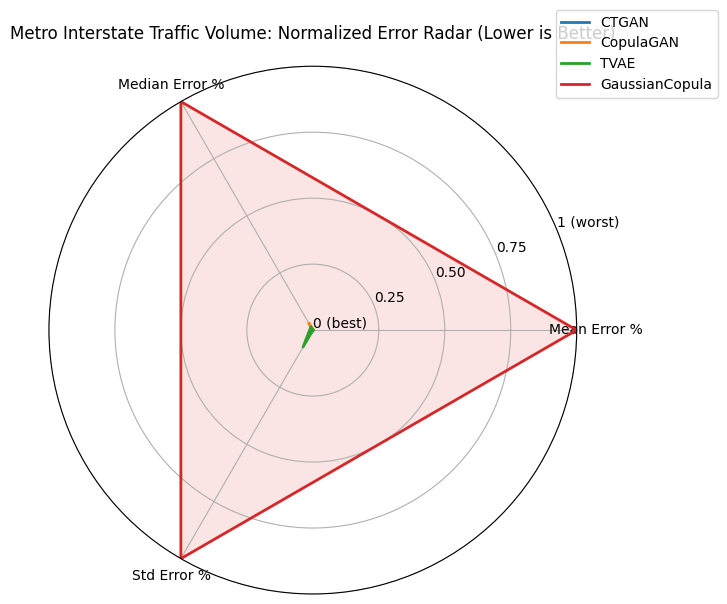

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.000000,0.000000,0.010439
1,CopulaGAN,0.002235,0.030344,0.000000
2,TVAE,0.000390,0.014575,0.074148
3,GaussianCopula,1.000000,1.000000,1.000000


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

radar_df = summary_df[["Model"] + metrics].copy()
radar_df = radar_df.set_index("Model").reindex(model_order).dropna(how="all").reset_index()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Metro Interstate Traffic Volume: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,10.75,5.0,33.0
1,CopulaGAN,15.75,5.0,53.0
2,TVAE,14.25,5.0,47.0
3,GaussianCopula,47.50,42.0,106.0


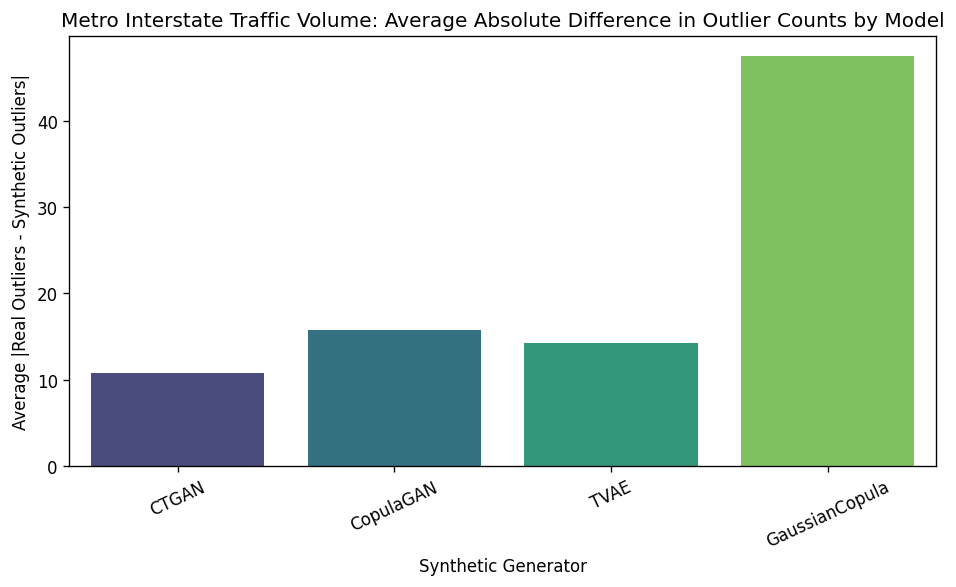

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .reindex(model_order)
    .reset_index()
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    order=model_order,
    palette="viridis"
)
plt.title("Metro Interstate Traffic Volume: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Synthetic Generator")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [32]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

target_col = "traffic_volume"

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = 2000
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.989758  0.999994  0.950277  0.955475  0.955947  0.969632  0.957312   
R2   0.989776  0.999994  0.950316  0.955512  0.955984  0.969663  0.957348   
R3   0.999717  0.993287  0.980618  0.983833  0.984119  0.991869  0.984939   
R4   0.988720  0.958228  0.999734  0.999982  0.999991  0.998918  0.999999   
R5   0.996206  0.974381  0.996279  0.997610  0.997720  0.999861  0.998024   
R6   0.995347  0.972229  0.997043  0.998214  0.998309  0.999973  0.998569   
R7   0.993138  0.967175  0.998421  0.999237  0.999298  0.999910  0.999462   
R8   0.989798  0.999995  0.950365  0.955558  0.956030  0.969701  0.957393   
R9   0.989799  0.999995  0.950368  0.955561  0.956033  0.969703  0.957396   
R10  0.989737  0.999993  0.950233  0.955433  0.955906  0.969597  0.957271   

           S8        S9       S10  
R1   0.999994  0.960834  0.952244  
R2   0.999994  0.960868  0.952

,avg_cosine,max_cosine
CTGAN,0.981376,1.0
CopulaGAN,0.981345,1.0
TVAE,0.980867,1.0
GaussianCopula,0.979833,1.0


In [33]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

target_col = "traffic_volume"

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R246 -> S1256   cosine similarity = 1.0000
02. R3229 -> S1256   cosine similarity = 1.0000
03. R4083 -> S1256   cosine similarity = 1.0000
04. R4513 -> S1256   cosine similarity = 1.0000
05. R312 -> S1256   cosine similarity = 1.0000
06. R3151 -> S1256   cosine similarity = 1.0000
07. R3379 -> S1256   cosine similarity = 1.0000
08. R4639 -> S1256   cosine similarity = 1.0000
09. R4681 -> S1256   cosine similarity = 1.0000
10. R2256 -> S1256   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R4229 -> S1447   cosine similarity = 1.0000
02. R4496 -> S1098   cosine similarity = 1.0000
03. R585 -> S582   cosine similarity = 1.0000
04. R898 -> S1084   cosine similarity = 1.0000
05. R4533 -> S821   cosine similarity = 1.0000
06. R325 -> S1562   cosine similarity = 1.0000
07. R1136 -> S1562   cosine similarity = 1.0000
08. R2698 -> S1126   cosine similarity = 1.0000
09. R3468 -> S1135   cosine similarity = 1.0000
10.

In [34]:
# Hungarian Mapping (Cosine) - Heart dataset setup

import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "traffic_volume"]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)
Average cosine similarity (Hungarian match): 0.9998

R246 <-> S124   cosine similarity = 1.0000
R4384 <-> S611   cosine similarity = 1.0000
R4478 <-> S1728   cosine similarity = 1.0000
R4711 <-> S1531   cosine similarity = 1.0000
R955 <-> S1105   cosine similarity = 1.0000
R3152 <-> S877   cosine similarity = 1.0000
R4121 <-> S1731   cosine similarity = 1.0000
R1615 <-> S1059   cosine similarity = 1.0000
R1856 <-> S1101   cosine similarity = 1.0000
R890 <-> S1760   cosine similarity = 1.0000

CopulaGAN: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)
Average cosine similarity (Hungarian match): 1.0000

R4769 <-> S1685   cosine similarity = 1.0000
R2972 <-> S1126   cosine similarity = 1.0000
R4245 <-> S1458   cosine similarity = 1.0000
R4962 <-> S1385   cosine similarity = 1.0000
R1428 <-> S1423   cosine similarity = 1.0000
R2104 <-> S1593   cosine similarity = 1.0000
R3

In [35]:
import pandas as pd
import numpy as np

target_col = "traffic_volume"

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Matchings_All_Models_Metro_Interstate_Traffic.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        model_res = results[model_name]

        # Support both:
        # (A) Hungarian-style results: row_ind/col_ind + similarities/distances
        # (B) Best-match results: best_indices/best_sims from cosine argmax approach
        if "row_ind" in model_res and "col_ind" in model_res:
            row_ind = np.asarray(model_res["row_ind"])
            col_ind = np.asarray(model_res["col_ind"])

            if "similarities" in model_res:
                score_key = "cosine_similarity"
                scores = np.asarray(model_res["similarities"])
            elif "distances" in model_res:
                score_key = "mahalanobis_distance"
                scores = np.asarray(model_res["distances"])
            else:
                raise KeyError(
                    f"No score array found for model {model_name}. "
                    "Expected 'similarities' or 'distances'."
                )

        elif "best_indices" in model_res and "best_sims" in model_res:
            row_ind = np.arange(len(model_res["best_indices"]))
            col_ind = np.asarray(model_res["best_indices"])
            score_key = "cosine_similarity"
            scores = np.asarray(model_res["best_sims"])
        else:
            raise KeyError(
                f"Unsupported results format for model {model_name}. "
                "Expected Hungarian keys or best-match keys."
            )

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Matchings_All_Models_Metro_Interstate_Traffic.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
1,CopulaGAN,2000,0.999983,1.000000,0.994743,1.0
0,CTGAN,2000,0.999812,1.000000,0.944371,1.0
2,TVAE,2000,0.995756,0.999593,0.779564,1.0
3,GaussianCopula,2000,0.992559,0.999999,0.774627,1.0


# 7. Mahalanobis distance with Hungrain Mapping  

In [36]:
import numpy as np
from numpy.linalg import inv, LinAlgError

target_col = "traffic_volume"

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real Metro feature data.")
print(f"Used features (excluding target): {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real Metro feature data.
Used features (excluding target): 4
Mean shape: (4,), Inv_cov shape: (4, 4)


In [37]:
mahalanobis_results = {}
target_col = "traffic_volume"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real Metro distribution (lower is better):")
display(summary)

Mahalanobis distance to real Metro distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,1.393000,1.302978,0.410697,0.241297,7.103646
CTGAN,1.497469,1.364955,0.802376,0.262317,8.751407
CopulaGAN,1.526630,1.327897,1.295737,0.134062,17.784370
GaussianCopula,27.919158,32.763876,10.829780,0.935645,39.947626


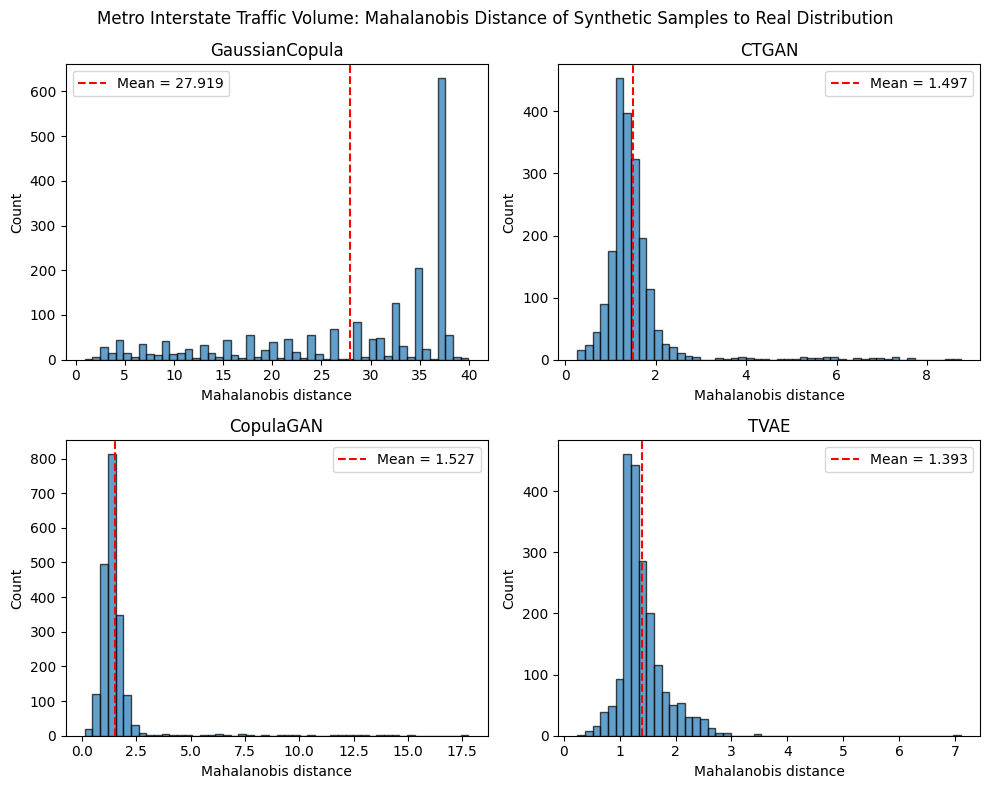

In [38]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Metro Interstate Traffic Volume: Mahalanobis Distance of Synthetic Samples to Real Distribution",
    fontsize=12
)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_metro_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [42]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

target_col = "traffic_volume"

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

# 🔧 FIX: take fixed 2000 sample from real data
real_full = data[num_cols].to_numpy(dtype=np.float64)
n_sample = 2000
real_idx = np.random.choice(len(real_full), size=n_sample, replace=False)
real_matrix = real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    # 🔧 ensure synthetic also 2000
    if synth_numeric.shape[0] >= n_sample:
        synth_numeric = synth_numeric[:n_sample]
    else:
        synth_numeric = synth_numeric[np.random.choice(len(synth_numeric), size=n_sample, replace=True)]

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Metro Interstate Traffic Volume - Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Metro Interstate Traffic Volume - Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
TVAE,0.291262,0.036889,1.533998,28.331044
CTGAN,0.399805,0.080421,1.436041,28.915857
CopulaGAN,0.482782,0.263329,1.455107,31.675494
GaussianCopula,27.790041,32.759063,11.047595,41.084586


In [43]:
# Fast Greedy mapping (subsampled + vectorized)

import numpy as np
import pandas as pd

target_col = "traffic_volume"

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)  # sorted candidate pairs by distance
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

# speed knob: reduce if still slow
MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Metro Interstate Traffic Volume - Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Metro Interstate Traffic Volume - Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,55706.435147,27.853218
CTGAN,863.249867,0.431625
CopulaGAN,1174.077680,0.587039
TVAE,516.868631,0.258434



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,2000,55706.435147,55580.081217,27.853218,27.790041,126.353930,0.063177
CTGAN,2000,863.249867,799.610360,0.431625,0.399805,63.639507,0.031820
CopulaGAN,2000,1174.077680,965.564898,0.587039,0.482782,208.512782,0.104256
TVAE,2000,516.868631,582.524794,0.258434,0.291262,-65.656164,-0.032828


In [44]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 4
GaussianCopula: avg matched Mahalanobis distance = 27.6541
CTGAN: avg matched Mahalanobis distance = 0.0682
CopulaGAN: avg matched Mahalanobis distance = 0.2621
TVAE: avg matched Mahalanobis distance = 0.0269


In [45]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 4
GaussianCopula: avg matched Mahalanobis distance = 27.6541
CTGAN: avg matched Mahalanobis distance = 0.0682
CopulaGAN: avg matched Mahalanobis distance = 0.2621
TVAE: avg matched Mahalanobis distance = 0.0269


In [46]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S710   distance = 0.0006
R2 -> No match found
R3 -> No match found
R4 -> S721   distance = 0.0030
R5 -> No match found
R6 -> No match found
R7 -> S1891   distance = 0.0261
R8 -> No match found
R9 -> No match found
R10 -> No match found
R11 -> S218   distance = 0.0089
R12 -> S86   distance = 0.0851
R13 -> No match found
R14 -> No match found
R15 -> No match found
R16 -> S307   distance = 0.0091
R17 -> No match found
R18 -> S1724   distance = 0.0089
R19 -> No match found
R20 -> S1640   distance = 0.0087

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> No match found
R2 -> No match found
R3 -> S308   distance = 0.2451
R4 -> S184   distance = 0.2211
R5 -> No match found
R6 -> No match found
R7 -> No match found
R8 -> S1864   distance = 0.2216
R9 -> No match found
R10 -> No match found
R11 -> S1409   distance = 0.2211
R12 -> S1350   distance = 0.2220
R13 -> No match found
R14 -> No match found
R15 -> S138   distance = 0.0450
R16 -> No mat

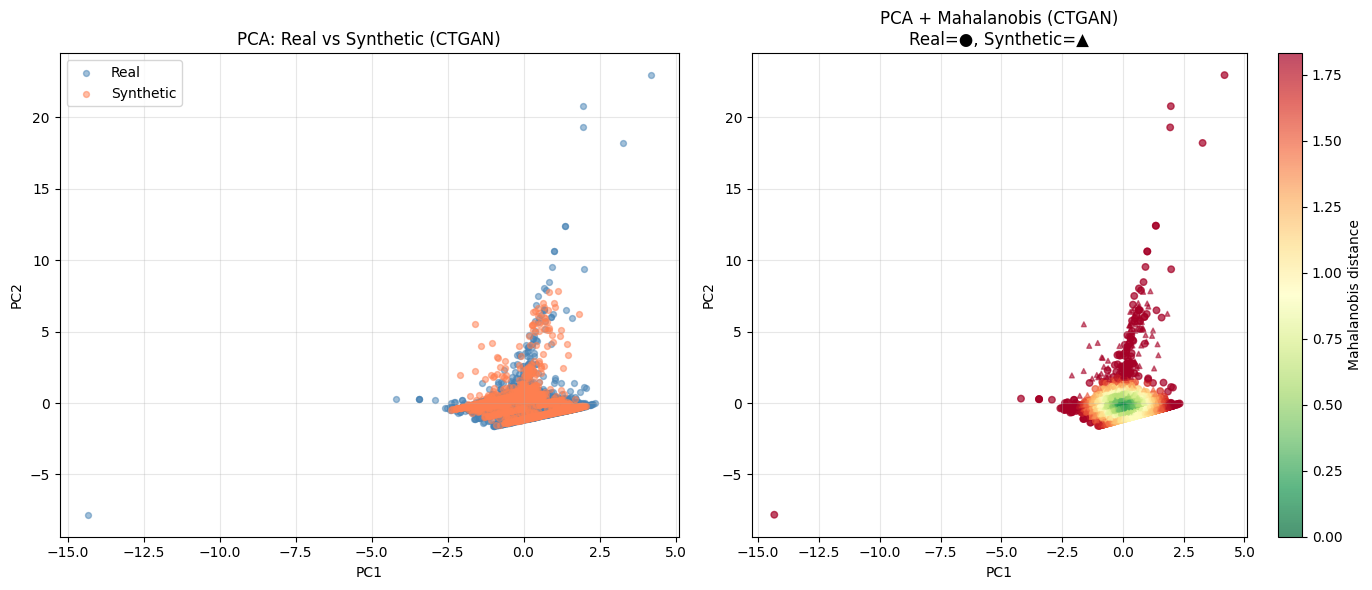

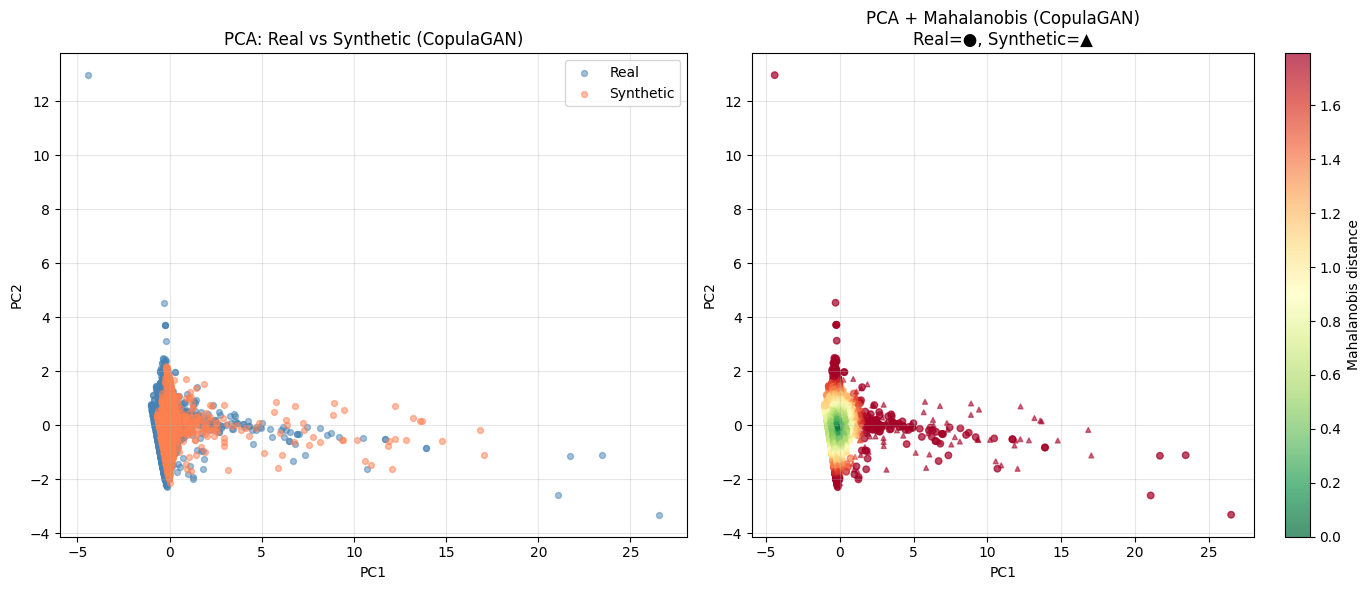

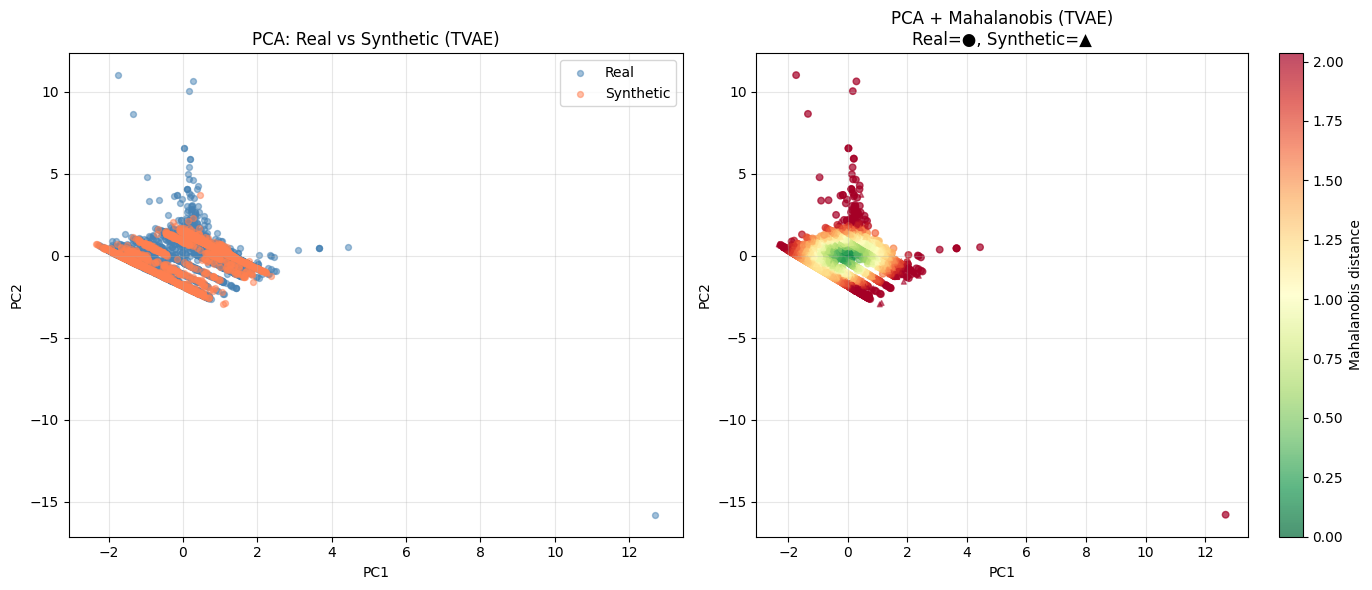

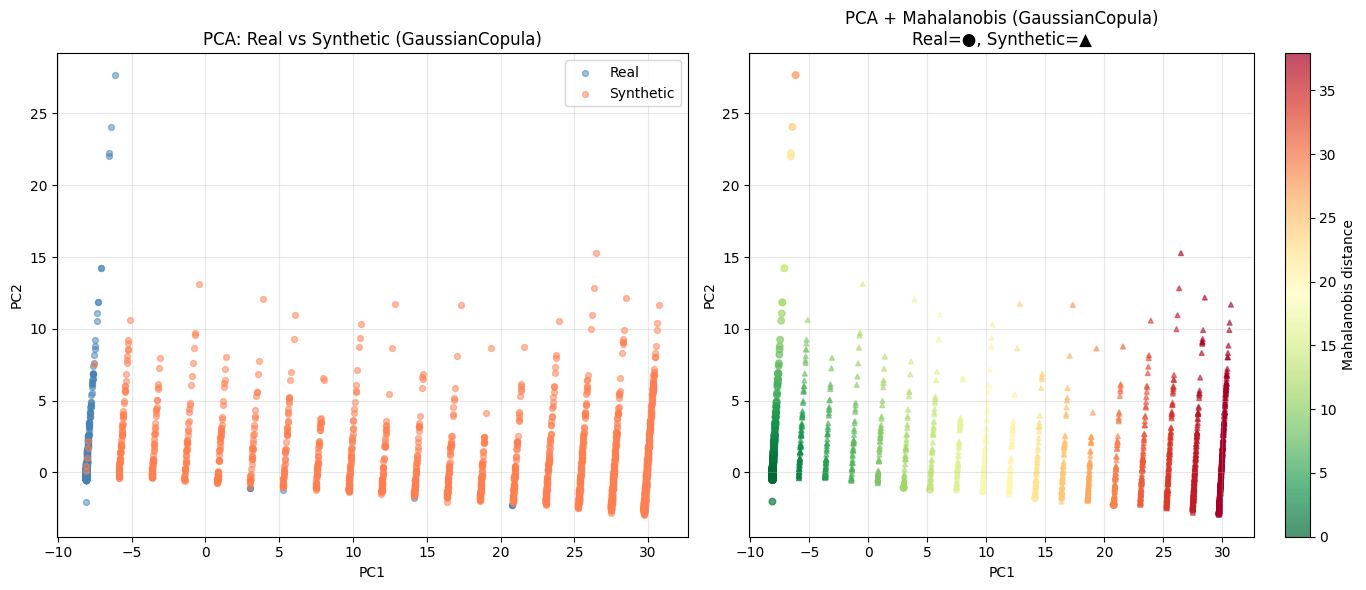

Metro Interstate Traffic Volume - PCA + Mahalanobis summary:


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,CopulaGAN,1.027443,1.130370,0.102928
0,CTGAN,1.123147,1.207920,0.084773
2,TVAE,1.285897,1.291210,0.005313
3,GaussianCopula,0.289209,28.494858,28.205649


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

target_col = "traffic_volume"

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
print("Metro Interstate Traffic Volume - PCA + Mahalanobis summary:")
display(summary_df)

In [48]:
# print results on excel sheets

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_Metro.xlsx"
):
    dataset_name = "Metro"
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"{dataset_name}_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name=f"{dataset_name}_Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
target_col = "traffic_volume"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary", target_col]]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_Metro.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_Metro.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [49]:
# MIA with ML regression model

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    y_pred = model.predict(X)
    # Per-sample squared error as attack signal (lower loss => more likely member)
    return (y - y_pred) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])  # higher => more likely member
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "traffic_volume"
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

real_df = data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=np.float64)
y_train = real_df[target_col].to_numpy(dtype=np.float64)

X_test = synth_df[feature_cols].to_numpy(dtype=np.float64)
y_test = synth_df[target_col].to_numpy(dtype=np.float64)

model = Ridge(alpha=1.0, random_state=42)
metrics = privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.5605445, 'Advantage': np.float64(0.11349999999999993), 'TPR_at_FPR_001': np.float64(0.012)}


In [50]:
# MIA with Mahalanobis

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "traffic_volume"

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("Metro Interstate Traffic Volume - MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

Metro Interstate Traffic Volume - MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,GaussianCopula,0.997511,0.9714,0.9760,1.454183,28.588990
1,CTGAN,0.548389,0.0866,0.0228,1.454183,1.497543
2,CopulaGAN,0.522254,0.0492,0.0198,1.454183,1.526698
3,TVAE,0.513421,0.0573,0.0306,1.454183,1.393070
